# DB-AFNO для горизонтальной двухфазной фильтрации на базе исходного блокнота

Численный генератор HR-данных сохранён из исходного блокнота. Изменена только нейросетевая часть: вместо ConvLSTM реализована dual-branch time-aware FNO/AFNO-схема из статьи с общей Fourier trunk, отдельными ветвями для $P$ и $S$, Time2Vec + causal Transformer и cross-gated fusion.

## 1. Математическая постановка

Ниже используется ровно модель из §1.2.1 диссертации для осреднённого по толщине пласта без капиллярных сил, тяжести, сжимаемости фаз и пористой среды.


define $D_p = [0,L_x]\times[0,L_y]$ and $\tau\in(0,T_p)$. Тогда:

\[
\frac{\partial v_x}{\partial x}+\frac{\partial v_y}{\partial y}=0,
\qquad
mH\frac{\partial S}{\partial \tau}+\frac{\partial v_{w,x}}{\partial x}+\frac{\partial v_{w,y}}{\partial y}=0,
\tag{1.2.1}
\]

\[
v_x=-HKK^*\frac{\partial P}{\partial x},\qquad
v_y=-HKK^*\frac{\partial P}{\partial y},\qquad
v_{w,x}=f\,v_x,\qquad
v_{w,y}=f\,v_y,
\tag{1.2.2}
\]

\[
K^*=\frac{K_w^*}{\mu_w}+\frac{K_n^*}{\mu_n},
\qquad
f=\frac{K_w^*}{\mu_w K^*},
\tag{1.2.3}
\]

\[
K_w^*(S)=
\begin{cases}
0, & 0\le S\le S_*,\\
\left(\dfrac{S-S_*}{S^*-S_*}\right)^{n_w}, & S_*\le S\le 1,
\end{cases}
\tag{1.2.4}
\]

\[
K_n^*(S)=
\begin{cases}
\left(\dfrac{S^*-S}{S^*-S_*}\right)^{n_n}, & 0\le S\le S^*,\\
0, & S^*\le S\le 1.
\end{cases}
\tag{1.2.5}
\]

Начальное условие:
\[
S(x,y,0)=S_0(x,y),\qquad S_*\le S_0\le S^*.
\tag{1.2.6}
\]

Граничные условия для насыщенности:
\[
S\big|_{\Gamma^{(+)}} = S^{(+)},
\qquad
S\big|_{\Gamma_{и,j}} = S^*,\quad j=1,\dots,M_и.
\tag{1.2.7}
\]

Граничные условия для давления:
\[
P\big|_{\Gamma}=P_\Gamma,
\tag{1.2.8}
\]
\[
P\big|_{\Gamma_{и,j}}=P^{зб}_{и,j},\quad j=1,\dots,M_и,
\tag{1.2.9}
\]
\[
P\big|_{\Gamma_{д,m}}=P^{зб}_{д,m},\quad m=1,\dots,M_д.
\tag{1.2.10}
\]

После решения задачи вычисляются расходы на добывающих скважинах:
\[
Q_{c,m}=\int_{\Gamma_{д,m}} KK^*\frac{\partial P}{\partial n}\,d\gamma,
\qquad
Q_{w,m}=\int_{\Gamma_{д,m}} fKK^*\frac{\partial P}{\partial n}\,d\gamma,
\quad m=1,\dots,M_д.
\tag{1.2.11}
\]

### Что именно реализовано в коде

- Давление решается из дискретного уравнения для `div(H K K^* grad P)=0` с **Dirichlet-условиями** на внешней границе и в скважинах.
- Насыщенность обновляется по **finite-volume/upwind** схеме для `mH S_t + div(v_w)=0`.
- На входных участках внешней границы `Γ(+)` поток воды использует заданную насыщенность `S(+)`.
- На инжекторе жёстко задаётся `S=S^*`.
- Внутренние цилиндрические поверхности скважин аппроксимируются **круговыми масками на декартовой сетке**. Это единственная геометрическая аппроксимация относительно непрерывной постановки.


In [1]:
import math, time, copy, os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
@dataclass
class Config:
    # grid / time
    nx_hr: int = 64
    ny_hr: int = 64
    nt_hr: int = 14
    s_up: int = 4
    t_up: int = 2

    # physical parameters from the model
    mu_w: float = 1.0
    mu_n: float = 4.0
    Swc: float = 0.20
    Smax: float = 0.90
    n_w: float = 3.0
    n_n: float = 2.0

    Pinj: float = 1.00
    Pprod: float = 0.22
    Pgamma: float = 0.22
    S_plus: float = 0.23

    H0: float = 1.0
    m0: float = 0.24

    # synthetic HR solver (оставлен без изменений)
    dt: float = 0.0025
    sat_substeps: int = 3
    n_pressure_iters: int = 260
    well_radius: int = 2
    n_cases: int = 20
    cfl: float = 0.45
    epsilon_sat: float = 1e-4
    epsilon_front: float = 0.05
    well_radius_phys: float = 0.02
    
    # DB-AFNO model (article-aligned)
    batch_size: int = 4
    fno_width: int = 64
    fno_layers: int = 8
    fno_modes_x_max: int = 18
    fno_modes_y_max: int = 18
    time_emb_dim: int = 64
    pressure_dropout: float = 0.2
    gamma_p_init: float = 2.0
    alpha_cross_init: float = 0.10
    beta_cross_init: float = 0.10

    # data / loss details from article
    huber_beta: float = 1e-2
    early_step_cutoff: int = 10
    early_step_factor: float = 2.0
    physics_tv_weight: float = 0.0

    # optimization from article
    lr: float = 5e-3
    weight_decay: float = 1e-2
    epochs: int = 25
    grad_clip: float = 2.0
    scheduler_t0: int = 100
    scheduler_tmult: int = 2
    scheduler_min_lr: float = 1e-8

    # curriculum from article
    curriculum_horizons: tuple = (25, 100, 500, 10**9)
    curriculum_phase_epochs: tuple = (50, 50, 50, 500)
    curriculum_modes: tuple = ((2, 2), (6, 6), (18, 18), (18, 18))

    # best-checkpoint selection only; article does not use early stopping
    checkpoint_metric: str = "score"

    # target thresholds, percent
    target_ff_P: float = 5.0
    target_ff_S: float = 8.0
    target_ff_joint: float = 7.0

cfg = Config()
cfg.nx_lr = cfg.nx_hr // cfg.s_up
cfg.ny_lr = cfg.ny_hr // cfg.s_up
cfg.nt_lr = math.ceil(cfg.nt_hr / cfg.t_up)
cfg.dx = 1.0 / (cfg.nx_hr - 1)
cfg.dy = 1.0 / (cfg.ny_hr - 1)

print(cfg)


Config(nx_hr=64, ny_hr=64, nt_hr=14, s_up=4, t_up=2, mu_w=1.0, mu_n=4.0, Swc=0.2, Smax=0.9, n_w=3.0, n_n=2.0, Pinj=1.0, Pprod=0.22, Pgamma=0.22, S_plus=0.23, H0=1.0, m0=0.24, dt=0.0025, sat_substeps=3, n_pressure_iters=260, well_radius=2, n_cases=20, cfl=0.45, epsilon_sat=0.0001, epsilon_front=0.05, well_radius_phys=0.02, batch_size=4, fno_width=64, fno_layers=8, fno_modes_x_max=18, fno_modes_y_max=18, time_emb_dim=64, pressure_dropout=0.2, gamma_p_init=2.0, alpha_cross_init=0.1, beta_cross_init=0.1, huber_beta=0.01, early_step_cutoff=10, early_step_factor=2.0, physics_tv_weight=0.0, lr=0.005, weight_decay=0.01, epochs=25, grad_clip=2.0, scheduler_t0=100, scheduler_tmult=2, scheduler_min_lr=1e-08, curriculum_horizons=(25, 100, 500, 1000000000), curriculum_phase_epochs=(50, 50, 50, 500), curriculum_modes=((2, 2), (6, 6), (18, 18), (18, 18)), checkpoint_metric='score', target_ff_P=5.0, target_ff_S=8.0, target_ff_joint=7.0)


## 2. Генератор HR-решения, согласованный с (1.2.1)–(1.2.11)


In [3]:
def smooth_noise(ny, nx, seed, sweeps=22):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(ny, nx))
    for _ in range(sweeps):
        z = (
            4.0 * z +
            np.roll(z, 1, 0) + np.roll(z, -1, 0) +
            np.roll(z, 1, 1) + np.roll(z, -1, 1)
        ) / 8.0
    z = (z - z.mean()) / (z.std() + 1e-8)
    return z


def circle_mask(ny, nx, cx, cy, radius):
    yy, xx = np.mgrid[0:ny, 0:nx]
    return (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2


def relperm_np(S, cfg):
    Se = np.clip((S - cfg.Swc) / (cfg.Smax - cfg.Swc), 0.0, 1.0)
    Kw = np.where(S <= cfg.Swc, 0.0, Se ** cfg.n_w)
    Kn = np.where(S >= cfg.Smax, 0.0, (1.0 - Se) ** cfg.n_n)
    return Kw.astype(np.float32), Kn.astype(np.float32)


def fw_from_s_np(S, cfg):
    Kw, Kn = relperm_np(S, cfg)
    lam_w = Kw / cfg.mu_w
    lam_n = Kn / cfg.mu_n
    lam_t = lam_w + lam_n + 1e-10
    return (lam_w / lam_t).astype(np.float32)


def make_coefficients(seed, cfg):
    x = np.linspace(0.0, 1.0, cfg.nx_hr)
    y = np.linspace(0.0, 1.0, cfg.ny_hr)
    X, Y = np.meshgrid(x, y)

    Kf = smooth_noise(cfg.ny_hr, cfg.nx_hr, seed=100 + seed, sweeps=24)
    Hf = smooth_noise(cfg.ny_hr, cfg.nx_hr, seed=200 + seed, sweeps=16)
    mf = smooth_noise(cfg.ny_hr, cfg.nx_hr, seed=300 + seed, sweeps=16)

    K = np.exp(0.45 * Kf)
    K /= K.mean()

    H = cfg.H0 * (1.0 + 0.12 * Hf)
    H = np.clip(H, 0.75, 1.25)

    m = cfg.m0 * (1.0 + 0.08 * mf)
    m = np.clip(m, 0.18, 0.30)

    inj_cx, inj_cy = int(0.18 * cfg.nx_hr), int(0.52 * cfg.ny_hr)
    prod_cx, prod_cy = int(0.82 * cfg.nx_hr), int(0.50 * cfg.ny_hr)

    inj_mask = circle_mask(cfg.ny_hr, cfg.nx_hr, inj_cx, inj_cy, cfg.well_radius)
    prod_mask = circle_mask(cfg.ny_hr, cfg.nx_hr, prod_cx, prod_cy, cfg.well_radius)

    S0 = cfg.Swc + 0.012
    S0 = S0 + 0.11 * np.exp(-((X - 0.18)**2 / 0.022 + (Y - 0.52)**2 / 0.034))
    S0 = S0 + 0.02 * np.exp(-((X - 0.30)**2 / 0.040 + (Y - 0.65)**2 / 0.045))
    S0 = np.clip(S0, cfg.Swc + 1e-4, cfg.Smax - 0.10)
    S0[inj_mask] = cfg.Smax

    return K.astype(np.float32), H.astype(np.float32), m.astype(np.float32), inj_mask, prod_mask, S0.astype(np.float32)


In [4]:

def _well_centers_from_masks(inj_mask, prod_mask):
    centers = []
    for mask, kind in [(inj_mask, "inj"), (prod_mask, "prod")]:
        pts = np.argwhere(mask)
        if len(pts) == 0:
            continue
        cy, cx = pts.mean(axis=0)
        centers.append((float(cx), float(cy), kind))
    return centers


def _zeta_from_r2(r2, cfg):
    if r2 <= 0.25:
        return 0.5 * np.pi / max(np.log(max(cfg.dx, cfg.dy) / max(cfg.well_radius_phys, 1e-6)), 1e-6)
    if abs(r2 - 1.25) < 1e-12:
        return 1.3378
    if abs(r2 - 2.25) < 1e-12:
        return 0.9284
    if r2 > 3.0:
        return 1.0
    # smooth fallback between tabulated values
    if r2 < 1.25:
        t = (r2 - 0.25) / 1.0
        return (1.0 - t) * (0.5 * np.pi / max(np.log(max(cfg.dx, cfg.dy) / max(cfg.well_radius_phys, 1e-6)), 1e-6)) + t * 1.3378
    t = (r2 - 1.25) / 1.0
    return (1.0 - t) * 1.3378 + t * 0.9284


def _zeta_face_array(shape, orientation, inj_mask, prod_mask, cfg):
    ny, nx = shape
    wells = _well_centers_from_masks(inj_mask, prod_mask)
    if orientation == "x":
        zeta = np.ones((ny, nx + 1), dtype=np.float32)
        for y in range(ny):
            for f in range(nx + 1):
                fx, fy = f - 0.5, y
                best = 1.0
                for cx, cy, _ in wells:
                    r2 = (cx - fx) ** 2 + (cy - fy) ** 2
                    best = _zeta_from_r2(r2, cfg) if r2 <= 3.0 else best
                    if r2 <= 3.0:
                        break
                zeta[y, f] = best
        return zeta
    zeta = np.ones((ny + 1, nx), dtype=np.float32)
    for f in range(ny + 1):
        for x in range(nx):
            fx, fy = x, f - 0.5
            best = 1.0
            for cx, cy, _ in wells:
                r2 = (cx - fx) ** 2 + (cy - fy) ** 2
                best = _zeta_from_r2(r2, cfg) if r2 <= 3.0 else best
                if r2 <= 3.0:
                    break
            zeta[f, x] = best
    return zeta


def solve_pressure(S, K, H, inj_mask, prod_mask, cfg):
    ny, nx = S.shape
    P = np.full((ny, nx), cfg.Pgamma, dtype=np.float32)
    P[inj_mask] = cfg.Pinj
    P[prod_mask] = cfg.Pprod

    Kw, Kn = relperm_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    a = H * K * lam_t + 1e-10

    zeta_x = _zeta_face_array(S.shape, "x", inj_mask, prod_mask, cfg)
    zeta_y = _zeta_face_array(S.shape, "y", inj_mask, prod_mask, cfg)

    fixed = np.zeros((ny, nx), dtype=bool)
    fixed[:, 0] = fixed[:, -1] = True
    fixed[0, :] = fixed[-1, :] = True
    fixed[inj_mask] = True
    fixed[prod_mask] = True

    omega = 0.8
    for _ in range(cfg.n_pressure_iters):
        Pn = P.copy()
        ae = zeta_x[1:-1, 2:nx] * 0.5 * (a[1:-1, 1:-1] + a[1:-1, 2:])
        aw = zeta_x[1:-1, 1:nx-1] * 0.5 * (a[1:-1, 1:-1] + a[1:-1, :-2])
        an = zeta_y[2:ny, 1:-1] * 0.5 * (a[1:-1, 1:-1] + a[2:, 1:-1])
        ass = zeta_y[1:ny-1, 1:-1] * 0.5 * (a[1:-1, 1:-1] + a[:-2, 1:-1])
        denom = ae + aw + an + ass + 1e-12
        core = (ae * P[1:-1, 2:] + aw * P[1:-1, :-2] + an * P[2:, 1:-1] + ass * P[:-2, 1:-1]) / denom
        Pn[1:-1, 1:-1] = (1.0 - omega) * P[1:-1, 1:-1] + omega * core

        Pn[:, 0] = cfg.Pgamma
        Pn[:, -1] = cfg.Pgamma
        Pn[0, :] = cfg.Pgamma
        Pn[-1, :] = cfg.Pgamma
        Pn[inj_mask] = cfg.Pinj
        Pn[prod_mask] = cfg.Pprod
        P = Pn

    return P.astype(np.float32), a.astype(np.float32), fixed


def total_flux_faces_np(P, a, cfg, inj_mask=None, prod_mask=None):
    ny, nx = P.shape
    if inj_mask is None:
        inj_mask = np.zeros_like(P, dtype=bool)
    if prod_mask is None:
        prod_mask = np.zeros_like(P, dtype=bool)

    zeta_x = _zeta_face_array(P.shape, "x", inj_mask, prod_mask, cfg)
    zeta_y = _zeta_face_array(P.shape, "y", inj_mask, prod_mask, cfg)

    qx = np.zeros((ny, nx + 1), dtype=np.float32)
    qy = np.zeros((ny + 1, nx), dtype=np.float32)

    a_x = 0.5 * (a[:, :-1] + a[:, 1:])
    qx[:, 1:nx] = -zeta_x[:, 1:nx] * a_x * (P[:, 1:] - P[:, :-1]) / cfg.dx
    qx[:, 0] = -zeta_x[:, 0] * a[:, 0] * (P[:, 0] - cfg.Pgamma) / (0.5 * cfg.dx)
    qx[:, nx] = -zeta_x[:, nx] * a[:, -1] * (cfg.Pgamma - P[:, -1]) / (0.5 * cfg.dx)

    a_y = 0.5 * (a[:-1, :] + a[1:, :])
    qy[1:ny, :] = -zeta_y[1:ny, :] * a_y * (P[1:, :] - P[:-1, :]) / cfg.dy
    qy[0, :] = -zeta_y[0, :] * a[0, :] * (P[0, :] - cfg.Pgamma) / (0.5 * cfg.dy)
    qy[ny, :] = -zeta_y[ny, :] * a[-1, :] * (cfg.Pgamma - P[-1, :]) / (0.5 * cfg.dy)
    return qx, qy


def _fractional_linear_face_value(j_prev, j_curr, j_opp, cfg):
    eps = cfg.epsilon_sat
    front = cfg.epsilon_front
    if j_curr >= cfg.Smax - front:
        return cfg.Smax
    if j_curr <= cfg.Swc + front:
        return cfg.Swc
    if j_prev >= j_curr:
        F = 0.5 * (j_prev + j_curr) * j_curr / max(j_prev, eps)
    else:
        F = 0.5 * (1.0 + j_curr - (1.0 - j_curr) ** 2 / max(1.0 - j_prev, eps))
    lo = min(j_curr, j_opp)
    hi = max(j_curr, j_opp)
    if F < lo or F > hi:
        return j_curr
    return float(np.clip(F, cfg.Swc, cfg.Smax))


def _face_saturation_x(S, qx, cfg):
    ny, nx = S.shape
    Sf = np.zeros((ny, nx + 1), dtype=np.float32)

    for y in range(ny):
        if qx[y, 0] > 0.0:
            Sf[y, 0] = cfg.S_plus
        else:
            Sf[y, 0] = S[y, 0]

        for f in range(1, nx):
            if qx[y, f] >= 0.0:
                j_curr = S[y, f - 1]
                j_prev = S[y, max(f - 2, 0)]
                j_opp = S[y, f]
            else:
                j_curr = S[y, f]
                j_prev = S[y, min(f + 1, nx - 1)]
                j_opp = S[y, f - 1]
            Sf[y, f] = _fractional_linear_face_value(j_prev, j_curr, j_opp, cfg)

        if qx[y, nx] < 0.0:
            Sf[y, nx] = cfg.S_plus
        else:
            Sf[y, nx] = S[y, -1]

    return np.clip(Sf, cfg.Swc, cfg.Smax)


def _face_saturation_y(S, qy, cfg):
    ny, nx = S.shape
    Sf = np.zeros((ny + 1, nx), dtype=np.float32)

    for x in range(nx):
        if qy[0, x] > 0.0:
            Sf[0, x] = cfg.S_plus
        else:
            Sf[0, x] = S[0, x]

        for f in range(1, ny):
            if qy[f, x] >= 0.0:
                j_curr = S[f - 1, x]
                j_prev = S[max(f - 2, 0), x]
                j_opp = S[f, x]
            else:
                j_curr = S[f, x]
                j_prev = S[min(f + 1, ny - 1), x]
                j_opp = S[f - 1, x]
            Sf[f, x] = _fractional_linear_face_value(j_prev, j_curr, j_opp, cfg)

        if qy[ny, x] < 0.0:
            Sf[ny, x] = cfg.S_plus
        else:
            Sf[ny, x] = S[-1, x]

    return np.clip(Sf, cfg.Swc, cfg.Smax)


def _apply_sector_well_update(S_new, S_old, qx, qy, cfg, prod_mask, H):
    pts = np.argwhere(prod_mask)
    if len(pts) == 0:
        return S_new
    cy, cx = np.round(pts.mean(axis=0)).astype(int)
    Hm = float(np.mean(H[prod_mask])) if np.any(prod_mask) else float(H[cy, cx])

    axial = [(1, 0), (-1, 0), (0, 1), (0, -1)]
    for dxs, dys in axial:
        x = cx + dxs
        y = cy + dys
        if not (0 <= x < S_new.shape[1] and 0 <= y < S_new.shape[0]):
            continue
        if prod_mask[y, x]:
            continue
        if dxs == 1:
            v_face = qx[y, min(x + 1, qx.shape[1] - 1)]
            s_face = _face_saturation_x(S_old, qx, cfg)[y, min(x + 1, qx.shape[1] - 1)]
        elif dxs == -1:
            v_face = qx[y, x]
            s_face = _face_saturation_x(S_old, qx, cfg)[y, x]
        elif dys == 1:
            v_face = qy[min(y + 1, qy.shape[0] - 1), x]
            s_face = _face_saturation_y(S_old, qy, cfg)[min(y + 1, qy.shape[0] - 1), x]
        else:
            v_face = qy[y, x]
            s_face = _face_saturation_y(S_old, qy, cfg)[y, x]
        f_cell = fw_from_s_np(np.array([[S_old[y, x]]], dtype=np.float32), cfg)[0, 0]
        f_face = fw_from_s_np(np.array([[s_face]], dtype=np.float32), cfg)[0, 0]
        S_new[y, x] = np.clip(S_old[y, x] + 4.0 * cfg.dt * v_face * (f_face - f_cell) / (3.0 * Hm * max(cfg.dx, cfg.dy) + 1e-12), cfg.Swc, cfg.Smax)

    diags = [(1, 1), (1, -1), (-1, 1), (-1, -1)]
    Sfx = _face_saturation_x(S_old, qx, cfg)
    Sfy = _face_saturation_y(S_old, qy, cfg)
    for dxs, dys in diags:
        x = cx + dxs
        y = cy + dys
        if not (0 <= x < S_new.shape[1] and 0 <= y < S_new.shape[0]):
            continue
        if prod_mask[y, x]:
            continue
        v1 = qx[y, x + 1] if dxs > 0 else qx[y, x]
        s1 = Sfx[y, x + 1] if dxs > 0 else Sfx[y, x]
        v2 = qy[y + 1, x] if dys > 0 else qy[y, x]
        s2 = Sfy[y + 1, x] if dys > 0 else Sfy[y, x]
        f_cell = fw_from_s_np(np.array([[S_old[y, x]]], dtype=np.float32), cfg)[0, 0]
        f1 = fw_from_s_np(np.array([[s1]], dtype=np.float32), cfg)[0, 0]
        f2 = fw_from_s_np(np.array([[s2]], dtype=np.float32), cfg)[0, 0]
        incr = 2.0 * cfg.dt * (v1 * (f1 - f_cell) + v2 * (f2 - f_cell)) / (3.0 * Hm * max(cfg.dx, cfg.dy) + 1e-12)
        S_new[y, x] = np.clip(S_old[y, x] + incr, cfg.Swc, cfg.Smax)

    return S_new


def water_flux_faces_tvd_np(S, qx, qy, cfg):
    Sx = _face_saturation_x(S, qx, cfg)
    Sy = _face_saturation_y(S, qy, cfg)
    Fwx = fw_from_s_np(Sx, cfg) * qx
    Fwy = fw_from_s_np(Sy, cfg) * qy
    return Fwx.astype(np.float32), Fwy.astype(np.float32)


def sat_rhs_tvd_np(S, P, K, H, m, inj_mask, prod_mask, cfg):
    S_work = np.clip(S, cfg.Swc, cfg.Smax).astype(np.float32)
    S_work[inj_mask] = cfg.Smax

    Kw, Kn = relperm_np(S_work, cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    a = H * K * lam_t + 1e-10
    qx, qy = total_flux_faces_np(P, a, cfg, inj_mask=inj_mask, prod_mask=prod_mask)
    Fwx, Fwy = water_flux_faces_tvd_np(S_work, qx, qy, cfg)
    div_w = (Fwx[:, 1:] - Fwx[:, :-1]) / cfg.dx + (Fwy[1:, :] - Fwy[:-1, :]) / cfg.dy

    rhs = -div_w / (m * H + 1e-10)
    rhs[inj_mask] = 0.0
    rhs[prod_mask] = 0.0
    return rhs.astype(np.float32), qx, qy, Fwx, Fwy


def update_saturation(S, P, K, H, m, inj_mask, prod_mask, cfg):
    Kw, Kn = relperm_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    a = H * K * lam_t + 1e-10
    qx, qy = total_flux_faces_np(P, a, cfg, inj_mask=inj_mask, prod_mask=prod_mask)
    vel = max(np.max(np.abs(qx)), np.max(np.abs(qy))) / (np.min(m * H) + 1e-10)
    dt = min(cfg.dt, cfg.cfl * min(cfg.dx, cfg.dy) / (vel + 1e-10))

    rhs, qx, qy, _, _ = sat_rhs_tvd_np(S, P, K, H, m, inj_mask, prod_mask, cfg)
    S_new = np.clip(S + dt * rhs, cfg.Swc, cfg.Smax).astype(np.float32)
    S_new[inj_mask] = cfg.Smax
    S_new = _apply_sector_well_update(S_new, np.clip(S, cfg.Swc, cfg.Smax), qx, qy, cfg, prod_mask, H)
    S_new[inj_mask] = cfg.Smax
    return np.clip(S_new, cfg.Swc, cfg.Smax).astype(np.float32)


def compute_producer_rates(P, S, K, H, prod_mask, cfg):
    Kw, Kn = relperm_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    a = H * K * lam_t + 1e-10
    qx, qy = total_flux_faces_np(P, a, cfg, prod_mask=prod_mask)
    Fwx, Fwy = water_flux_faces_tvd_np(np.clip(S, cfg.Swc, cfg.Smax), qx, qy, cfg)

    q_total = 0.0
    q_water = 0.0
    ny, nx = P.shape
    for y, x in np.argwhere(prod_mask):
        if x > 0 and not prod_mask[y, x - 1]:
            q_total += qx[y, x]
            q_water += Fwx[y, x]
        if x < nx - 1 and not prod_mask[y, x + 1]:
            q_total -= qx[y, x + 1]
            q_water -= Fwx[y, x + 1]
        if y > 0 and not prod_mask[y - 1, x]:
            q_total += qy[y, x]
            q_water += Fwy[y, x]
        if y < ny - 1 and not prod_mask[y + 1, x]:
            q_total -= qy[y + 1, x]
            q_water -= Fwy[y + 1, x]
    return float(q_total), float(q_water)


def simulate_case(seed, cfg):
    K, H, m, inj_mask, prod_mask, S = make_coefficients(seed, cfg)
    P_seq, S_seq, qc_seq, qw_seq = [], [], [], []

    for _ in range(cfg.nt_hr):
        P, a, fixed = solve_pressure(S, K, H, inj_mask, prod_mask, cfg)
        qc, qw = compute_producer_rates(P, S, K, H, prod_mask, cfg)
        P_seq.append(P.copy())
        S_seq.append(S.copy())
        qc_seq.append(qc)
        qw_seq.append(qw)

        for _ in range(cfg.sat_substeps):
            S = update_saturation(S, P, K, H, m, inj_mask, prod_mask, cfg)

    hr = np.stack([np.stack(P_seq, axis=0), np.stack(S_seq, axis=0)], axis=1)
    meta = {
        "K": K, "H": H, "m": m,
        "inj": inj_mask, "prod": prod_mask,
        "Qc": np.array(qc_seq, dtype=np.float32),
        "Qw": np.array(qw_seq, dtype=np.float32),
        "watercut": np.array(qw_seq, dtype=np.float32) / (np.array(qc_seq, dtype=np.float32) + 1e-10),
    }
    return hr.astype(np.float32), meta


In [5]:
import os
import json
import inspect
from pathlib import Path
from types import SimpleNamespace

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader



DATA_DIR = Path(
    os.environ.get(
        "FILTRATION_DATA_DIR",
        os.path.expanduser("~/workspaces/artem/synth64_break_8_3"),
    )
)

NAME = os.environ.get("FILTRATION_DATASET_NAME", "synth128_x8_t3")

CONFIG_PATH = DATA_DIR / "config.json"
NORMALIZATION_PATH = DATA_DIR / "normalization.json"
TRAIN_H5 = DATA_DIR / f"{NAME}_train.h5"
VAL_H5 = DATA_DIR / f"{NAME}_val.h5"
TEST_H5 = DATA_DIR / f"{NAME}_test.h5"

USING_H5_DATASET = True


def require_file(path):
    path = Path(path)
    if not path.exists():
        available = "\n".join(p.name for p in DATA_DIR.glob("*")) if DATA_DIR.exists() else "DATA_DIR does not exist"
        raise FileNotFoundError(
            f"Missing file: {path}\n\nDATA_DIR: {DATA_DIR}\nAvailable files:\n{available}"
        )


for path in [CONFIG_PATH, TRAIN_H5, VAL_H5, TEST_H5]:
    require_file(path)


def make_cfg_from_json(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    if "Config" in globals():
        sig = inspect.signature(Config)
        allowed = set(sig.parameters.keys())
        init_kwargs = {k: v for k, v in d.items() if k in allowed}
        cfg = Config(**init_kwargs)

        for k, v in d.items():
            if not hasattr(cfg, k):
                setattr(cfg, k, v)

        if hasattr(cfg, "finalize"):
            cfg = cfg.finalize()
    else:
        cfg = SimpleNamespace(**d)

    cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

    if not hasattr(cfg, "batch_size"):
        cfg.batch_size = 1

    return cfg


cfg = make_cfg_from_json(CONFIG_PATH)


CORE_KEYS = [
    "lr", "hr",
    "K", "H", "m",
    "inj", "prod",
    "Qc", "Qw", "watercut",
    "dt_frame", "dt_substep", "traj",
]

OPTIONAL_KEYS = [
    "valid_mask", "valid_lr_mask",
    "time",
    "breakthrough_reached",
    "breakthrough_frame",
    "breakthrough_time",
    "n_valid_frames",
]


class H5FiltrationDataset(Dataset):
    def __init__(self, path, keys=None):
        self.path = str(path)

        with h5py.File(self.path, "r") as f:
            self.length = int(f["hr"].shape[0])
            self.available_keys = set(f.keys())

        if keys is None:
            keys = CORE_KEYS + [k for k in OPTIONAL_KEYS if k in self.available_keys]

        self.keys = [k for k in keys if k in self.available_keys]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        item = {}

        with h5py.File(self.path, "r") as f:
            for key in self.keys:
                arr = f[key][idx]

                if key in ["inj", "prod", "breakthrough_reached"]:
                    item[key] = torch.as_tensor(arr, dtype=torch.bool)
                elif key in ["breakthrough_frame", "n_valid_frames"]:
                    item[key] = torch.as_tensor(arr, dtype=torch.long)
                else:
                    item[key] = torch.as_tensor(arr, dtype=torch.float32)

        return item


def sync_cfg_with_h5(cfg, h5_path):
    with h5py.File(h5_path, "r") as f:
        _, nt_hr, _, ny_hr, nx_hr = f["hr"].shape
        _, nt_lr, _, ny_lr, nx_lr = f["lr"].shape

    cfg.nx_hr = int(nx_hr)
    cfg.ny_hr = int(ny_hr)
    cfg.nt_hr = int(nt_hr)

    cfg.nx_lr = int(nx_lr)
    cfg.ny_lr = int(ny_lr)
    cfg.nt_lr = int(nt_lr)

    cfg.s_up = int(round(nx_hr / nx_lr))
    cfg.t_up = max(1, int(round((nt_hr - 1) / max(nt_lr - 1, 1))))

    cfg.dx = 1.0 / max(1, cfg.nx_hr - 1)
    cfg.dy = 1.0 / max(1, cfg.ny_hr - 1)

    cfg.fno_modes_x_max = min(int(getattr(cfg, "fno_modes_x_max", 18)), cfg.ny_hr)
    cfg.fno_modes_y_max = min(int(getattr(cfg, "fno_modes_y_max", 18)), cfg.nx_hr // 2 + 1)

    cfg.curriculum_modes = tuple(
        (min(int(mx), cfg.fno_modes_x_max), min(int(my), cfg.fno_modes_y_max))
        for mx, my in getattr(
            cfg,
            "curriculum_modes",
            ((2, 2), (6, 6), (18, 18), (18, 18)),
        )
    )

    return cfg


def compute_mean_std_h5(path, chunk_size=16):
    with h5py.File(path, "r") as f:
        hr = f["hr"]
        n, t, c, h, w = hr.shape

        total = n * t * h * w
        sums = np.zeros(c, dtype=np.float64)
        sqs = np.zeros(c, dtype=np.float64)

        for i0 in range(0, n, chunk_size):
            x = hr[i0:i0 + chunk_size].astype(np.float64)
            sums += x.sum(axis=(0, 1, 3, 4))
            sqs += (x ** 2).sum(axis=(0, 1, 3, 4))

        mean_np = sums / total
        var_np = sqs / total - mean_np ** 2
        std_np = np.sqrt(np.maximum(var_np, 1e-12)) + 1e-6

    return (
        torch.tensor(mean_np, dtype=torch.float32),
        torch.tensor(std_np, dtype=torch.float32),
    )


def compute_static_mean_std_h5(path, chunk_size=16):
    sums = np.zeros(5, dtype=np.float64)
    sqs = np.zeros(5, dtype=np.float64)
    total = 0

    with h5py.File(path, "r") as f:
        n = f["hr"].shape[0]

        for i0 in range(0, n, chunk_size):
            sl = slice(i0, min(i0 + chunk_size, n))

            K = f["K"][sl].astype(np.float64)
            H = f["H"][sl].astype(np.float64)
            m = f["m"][sl].astype(np.float64)
            inj = f["inj"][sl].astype(np.float64)
            prod = f["prod"][sl].astype(np.float64)

            static = np.stack([np.log1p(K), H, m, inj, prod], axis=1)

            sums += static.sum(axis=(0, 2, 3))
            sqs += (static ** 2).sum(axis=(0, 2, 3))
            total += static.shape[0] * static.shape[2] * static.shape[3]

    mean_np = sums / total
    var_np = sqs / total - mean_np ** 2
    std_np = np.sqrt(np.maximum(var_np, 1e-12)) + 1e-6

    return (
        torch.tensor(mean_np, dtype=torch.float32),
        torch.tensor(std_np, dtype=torch.float32),
    )


def load_or_compute_state_normalization(data_dir, train_h5):
    norm_path = Path(data_dir) / "normalization.json"

    if norm_path.exists():
        with open(norm_path, "r", encoding="utf-8") as f:
            d = json.load(f)

        if "mean" in d and "std" in d:
            state_mean = torch.tensor(d["mean"], dtype=torch.float32)
            state_std = torch.tensor(d["std"], dtype=torch.float32)
        elif "state_mean" in d and "state_std" in d:
            state_mean = torch.tensor(d["state_mean"], dtype=torch.float32)
            state_std = torch.tensor(d["state_std"], dtype=torch.float32)
        else:
            raise KeyError(
                f"Unsupported normalization.json keys: {list(d.keys())}. "
                "Expected mean/std or state_mean/state_std."
            )
    else:
        state_mean, state_std = compute_mean_std_h5(train_h5)

    return state_mean, state_std


cfg = sync_cfg_with_h5(cfg, TRAIN_H5)

train_ds = H5FiltrationDataset(TRAIN_H5)
val_ds = H5FiltrationDataset(VAL_H5)
test_ds = H5FiltrationDataset(TEST_H5)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

state_mean, state_std = load_or_compute_state_normalization(DATA_DIR, TRAIN_H5)
target_mean = state_mean.clone()
target_std = state_std.clone()
static_mean, static_std = compute_static_mean_std_h5(TRAIN_H5)

mean = state_mean
std = state_std

print("Dataset:", NAME)
print("DATA_DIR:", DATA_DIR)
print("CONFIG_PATH:", CONFIG_PATH)
print("TRAIN_H5:", TRAIN_H5)
print("VAL_H5:", VAL_H5)
print("TEST_H5:", TEST_H5)
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
print("HR:", (cfg.nt_hr, 2, cfg.ny_hr, cfg.nx_hr))
print("LR:", (cfg.nt_lr, 2, cfg.ny_lr, cfg.nx_lr))
print("s_up:", cfg.s_up)
print("t_up:", cfg.t_up)
print("sat_substeps:", getattr(cfg, "sat_substeps", None))
print("dt:", getattr(cfg, "dt", None))
print("batch_size:", cfg.batch_size)
print("state mean:", state_mean)
print("state std :", state_std)
print("static mean:", static_mean)
print("static std :", static_std)

batch = next(iter(train_loader))

print("batch keys:", list(batch.keys()))
print("lr:", batch["lr"].shape)
print("hr:", batch["hr"].shape)
print("K :", batch["K"].shape)
print("traj:", batch["traj"].shape if "traj" in batch else None)

Dataset: synth128_x8_t3
DATA_DIR: /home/anywherevla/workspaces/artem/synth64_break_8_3
CONFIG_PATH: /home/anywherevla/workspaces/artem/synth64_break_8_3/config.json
TRAIN_H5: /home/anywherevla/workspaces/artem/synth64_break_8_3/synth128_x8_t3_train.h5
VAL_H5: /home/anywherevla/workspaces/artem/synth64_break_8_3/synth128_x8_t3_val.h5
TEST_H5: /home/anywherevla/workspaces/artem/synth64_break_8_3/synth128_x8_t3_test.h5
train/val/test: 112 22 16
HR: (30, 2, 64, 64)
LR: (10, 2, 8, 8)
s_up: 8
t_up: 3
sat_substeps: 100
dt: 0.0025
batch_size: 4
state mean: tensor([0.3577, 0.4082])
state std : tensor([0.1577, 0.2459])
static mean: tensor([0.6230, 1.0009, 0.2400, 0.0032, 0.0032])
static std : tensor([0.3342, 0.1220, 0.0220, 0.0562, 0.0562])
batch keys: ['lr', 'hr', 'K', 'H', 'm', 'inj', 'prod', 'Qc', 'Qw', 'watercut', 'dt_frame', 'dt_substep', 'traj']
lr: torch.Size([4, 10, 2, 8, 8])
hr: torch.Size([4, 30, 2, 64, 64])
K : torch.Size([4, 64, 64])
traj: torch.Size([4, 2901, 2, 64, 64])


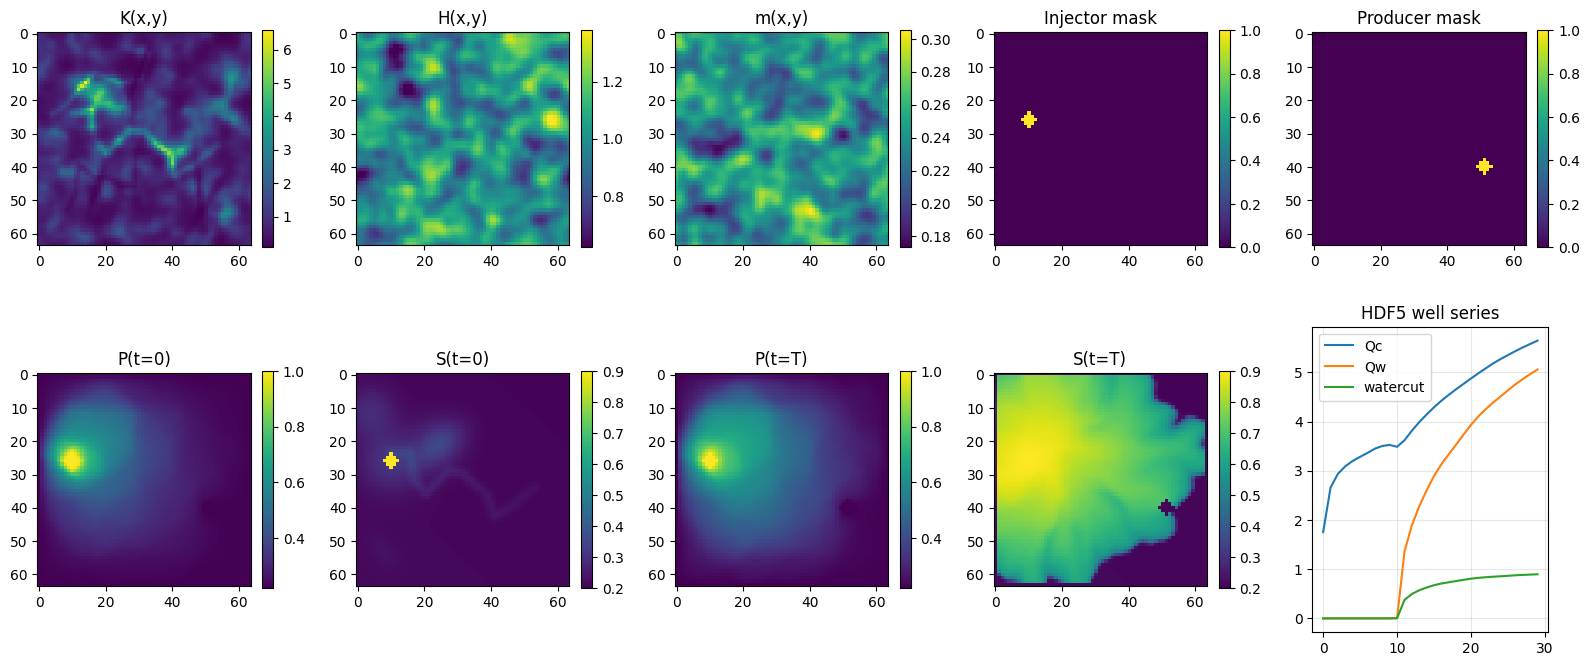

In [6]:
case_id = 0
sample0 = train_ds[case_id]


def _as_np(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


lr0 = _as_np(sample0["lr"])
hr0 = _as_np(sample0["hr"])
meta0 = {k: _as_np(sample0[k]) for k in sample0 if k not in ["lr", "hr"]}

t0, t1 = 0, cfg.nt_hr - 1

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
ax = axes.ravel()

im0 = ax[0].imshow(meta0["K"]); ax[0].set_title("K(x,y)"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(meta0["H"]); ax[1].set_title("H(x,y)"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
im2 = ax[2].imshow(meta0["m"]); ax[2].set_title("m(x,y)"); plt.colorbar(im2, ax=ax[2], fraction=0.046)
im3 = ax[3].imshow(meta0["inj"]); ax[3].set_title("Injector mask"); plt.colorbar(im3, ax=ax[3], fraction=0.046)
im4 = ax[4].imshow(meta0["prod"]); ax[4].set_title("Producer mask"); plt.colorbar(im4, ax=ax[4], fraction=0.046)

im5 = ax[5].imshow(hr0[t0, 0]); ax[5].set_title("P(t=0)"); plt.colorbar(im5, ax=ax[5], fraction=0.046)
im6 = ax[6].imshow(hr0[t0, 1], vmin=cfg.Swc, vmax=cfg.Smax); ax[6].set_title("S(t=0)"); plt.colorbar(im6, ax=ax[6], fraction=0.046)
im7 = ax[7].imshow(hr0[t1, 0]); ax[7].set_title("P(t=T)"); plt.colorbar(im7, ax=ax[7], fraction=0.046)
im8 = ax[8].imshow(hr0[t1, 1], vmin=cfg.Swc, vmax=cfg.Smax); ax[8].set_title("S(t=T)"); plt.colorbar(im8, ax=ax[8], fraction=0.046)

if "Qc" in meta0:
    ax[9].plot(meta0["Qc"], label="Qc")
if "Qw" in meta0:
    ax[9].plot(meta0["Qw"], label="Qw")
if "watercut" in meta0:
    ax[9].plot(meta0["watercut"], label="watercut")
ax[9].set_title("HDF5 well series")
ax[9].grid(True, alpha=0.3)
ax[9].legend()

plt.tight_layout()
plt.show()

## 3. Датасет и нормировка

In [7]:
# Датасет, DataLoader'ы и нормировки уже созданы из HDF5 выше.
# Эти имена используются дальше без изменений архитектуры DB-AFNO:
# train_ds, val_ds, test_ds, train_loader, val_loader, test_loader
# state_mean, state_std, target_mean, target_std, static_mean, static_std

assert len(train_ds) > 0
assert len(val_ds) > 0
assert len(test_ds) > 0

print("H5 dataset is ready.")
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
print("state mean/std:", state_mean, state_std)
print("target mean/std:", target_mean, target_std)
print("static mean/std:", static_mean, static_std)

H5 dataset is ready.
train/val/test: 112 22 16
state mean/std: tensor([0.3577, 0.4082]) tensor([0.1577, 0.2459])
target mean/std: tensor([0.3577, 0.4082]) tensor([0.1577, 0.2459])
static mean/std: tensor([0.6230, 1.0009, 0.2400, 0.0032, 0.0032]) tensor([0.3342, 0.1220, 0.0220, 0.0562, 0.0562])


## 4. DB-AFNO-архитектура из статьи

Здесь ConvLSTM-часть заменена на dual-branch архитектуру: общий Fourier trunk, Time2Vec + causal Transformer для временного контекста, saturation-ветка через spectral/iFFT-путь и pressure-ветка через convolutional decoder с dropout. Численный решатель генератора данных не меняется.

In [8]:
class ChannelNorm(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean.view(1, 1, -1, 1, 1))
        self.register_buffer("std", std.view(1, 1, -1, 1, 1))

    def encode(self, x):
        return (x - self.mean) / self.std

    def decode(self, x):
        return x * self.std + self.mean


class SpatialNorm(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean.view(1, -1, 1, 1))
        self.register_buffer("std", std.view(1, -1, 1, 1))

    def encode(self, x):
        return (x - self.mean) / self.std


def temporal_interp(x, t_out):
    b, t, c, h, w = x.shape
    z = x.permute(0, 2, 3, 4, 1).reshape(b * c * h * w, 1, t)
    z = F.interpolate(z, size=t_out, mode="linear", align_corners=True)
    z = z.reshape(b, c, h, w, t_out).permute(0, 4, 1, 2, 3)
    return z


def spatial_interp(x, size_hw):
    b, t, c, h, w = x.shape
    z = x.reshape(b * t, c, h, w)
    z = F.interpolate(z, size=size_hw, mode="bicubic", align_corners=True)
    z = z.reshape(b, t, c, size_hw[0], size_hw[1])
    return z


class Time2Vec(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear_w = nn.Parameter(torch.randn(1))
        self.linear_b = nn.Parameter(torch.zeros(1))
        self.periodic_w = nn.Parameter(torch.randn(dim - 1))
        self.periodic_b = nn.Parameter(torch.zeros(dim - 1))

    def forward(self, t):
        v0 = self.linear_w * t + self.linear_b
        vp = torch.sin(t * self.periodic_w + self.periodic_b)
        return torch.cat([v0, vp], dim=-1)


class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1_max, modes2_max):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1_max = modes1_max
        self.modes2_max = modes2_max
        self.active_m1 = modes1_max
        self.active_m2 = modes2_max
        scale = 1.0 / max(1, in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1_max, modes2_max, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1_max, modes2_max, dtype=torch.cfloat))

    def set_active_modes(self, modes1, modes2):
        self.active_m1 = min(int(modes1), self.modes1_max)
        self.active_m2 = min(int(modes2), self.modes2_max)

    def compl_mul2d(self, input_ft, weights):
        return torch.einsum("bixy,ioxy->boxy", input_ft, weights)

    def forward(self, x):
        b, _, h, w = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(
            b,
            self.out_channels,
            h,
            w // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        m1 = min(self.active_m1, h)
        m2 = min(self.active_m2, w // 2 + 1)
        out_ft[:, :, :m1, :m2] = self.compl_mul2d(x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = self.compl_mul2d(x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])
        return torch.fft.irfft2(out_ft, s=(h, w), norm="ortho")


class AFNOBlock2d(nn.Module):
    def __init__(self, width, modes1_max, modes2_max):
        super().__init__()
        self.norm_spec = nn.GroupNorm(width, width)
        self.norm_dw = nn.GroupNorm(width, width)
        self.spectral = SpectralConv2d(width, width, modes1_max, modes2_max)
        self.depthwise = nn.Conv2d(width, width, 3, padding=1, groups=width)
        self.pointwise = nn.Conv2d(width, width, 1)
        self.mix = nn.Conv2d(width, width, 1)

    def set_active_modes(self, modes1, modes2):
        self.spectral.set_active_modes(modes1, modes2)

    def forward(self, x):
        xs = self.spectral(self.norm_spec(x))
        xd = self.pointwise(self.depthwise(self.norm_dw(x)))
        y = F.gelu(xs + xd)
        return x + self.mix(y)


class SaturationDecoder(nn.Module):
    def __init__(self, width, modes1_max, modes2_max):
        super().__init__()
        self.spec = SpectralConv2d(width, width, modes1_max, modes2_max)
        self.mlp = nn.Sequential(
            nn.Conv2d(width, width, 1),
            nn.GELU(),
            nn.Conv2d(width, width // 2, 1),
            nn.GELU(),
            nn.Conv2d(width // 2, 1, 1),
        )

    def set_active_modes(self, modes1, modes2):
        self.spec.set_active_modes(modes1, modes2)

    def forward(self, x):
        x = F.gelu(self.spec(x))
        return self.mlp(x)


class PressureDecoder(nn.Module):
    def __init__(self, width, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(width, width, 3, padding=1),
            nn.BatchNorm2d(width),
            nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(width, width // 2, 3, padding=1),
            nn.BatchNorm2d(width // 2),
            nn.GELU(),
            nn.Conv2d(width // 2, 1, 1),
        )

    def forward(self, x):
        return self.net(x)


class DBAFNOModel(nn.Module):
    def __init__(self, state_mean, state_std, static_mean, static_std, cfg):
        super().__init__()
        self.cfg = cfg
        self.state_norm = ChannelNorm(state_mean, state_std)
        self.target_norm = ChannelNorm(target_mean.to(state_mean), target_std.to(state_std))
        self.static_norm = SpatialNorm(static_mean, static_std)

        self.time2vec = Time2Vec(cfg.time_emb_dim)
        self.dt_proj = nn.Linear(1, cfg.time_emb_dim)
        self.shared_temporal_encoder = self._make_temporal_encoder(cfg.time_emb_dim)
        self.sat_temporal_encoder = self._make_temporal_encoder(cfg.time_emb_dim)
        self.pres_temporal_encoder = self._make_temporal_encoder(cfg.time_emb_dim)

        self.input_proj = nn.Conv2d(2 + 5 + 2, cfg.fno_width, 1)
        self.shared_time_proj = nn.Linear(cfg.time_emb_dim, cfg.fno_width)
        self.sat_time_proj = nn.Linear(cfg.time_emb_dim, cfg.fno_width)
        self.pres_time_proj = nn.Linear(cfg.time_emb_dim, cfg.fno_width)

        self.blocks = nn.ModuleList([
            AFNOBlock2d(cfg.fno_width, cfg.fno_modes_x_max, cfg.fno_modes_y_max)
            for _ in range(cfg.fno_layers)
        ])
        self.sat_decoder = SaturationDecoder(cfg.fno_width, cfg.fno_modes_x_max, cfg.fno_modes_y_max)
        self.pres_decoder = PressureDecoder(cfg.fno_width, dropout=cfg.pressure_dropout)

        self.gamma_p = nn.Parameter(torch.tensor(cfg.gamma_p_init, dtype=torch.float32))
        self.alpha_cross = nn.Parameter(torch.tensor(cfg.alpha_cross_init, dtype=torch.float32))
        self.beta_cross = nn.Parameter(torch.tensor(cfg.beta_cross_init, dtype=torch.float32))
        self.s_gate = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.GELU(), nn.Conv2d(8, 1, 1))
        self.p_gate = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.GELU(), nn.Conv2d(8, 1, 1))
        self.register_buffer("grid", self._make_grid(cfg.ny_hr, cfg.nx_hr))
        self.set_active_modes(cfg.curriculum_modes[0][0], cfg.curriculum_modes[0][1])

    def _make_temporal_encoder(self, dim):
        enc_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=4,
            dim_feedforward=4 * dim,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        return nn.TransformerEncoder(enc_layer, num_layers=2)

    def set_active_modes(self, modes1, modes2):
        for block in self.blocks:
            block.set_active_modes(modes1, modes2)
        self.sat_decoder.set_active_modes(modes1, modes2)
        self.active_modes = (int(modes1), int(modes2))

    def _make_grid(self, ny, nx):
        y = torch.linspace(-1.0, 1.0, ny)
        x = torch.linspace(-1.0, 1.0, nx)
        yy, xx = torch.meshgrid(y, x, indexing="ij")
        return torch.stack([xx, yy], dim=0)

    def _causal_encode(self, encoder, emb):
        t = emb.shape[1]
        mask = torch.triu(torch.ones(t, t, device=emb.device, dtype=torch.bool), diagonal=1)
        return encoder(emb, mask=mask)

    def _time_context(self, b, t, device, dtype):
        tau = torch.linspace(0.0, 1.0, t, device=device, dtype=dtype).view(1, t, 1).expand(b, -1, -1)
        dt = torch.full_like(tau, 1.0 / max(1, t - 1))
        base = self.time2vec(tau) + self.dt_proj(dt)
        shared_ctx = self._causal_encode(self.shared_temporal_encoder, base)
        sat_ctx = self._causal_encode(self.sat_temporal_encoder, base)
        pres_ctx = self._causal_encode(self.pres_temporal_encoder, base)
        return shared_ctx, sat_ctx, pres_ctx

    def _static_features(self, K, H, m, inj_mask, prod_mask):
        feats = torch.stack([
            torch.log1p(K),
            H,
            m,
            inj_mask.float(),
            prod_mask.float(),
        ], dim=1)
        return self.static_norm.encode(feats)

    def forward(self, lr, K, H, m, inj_mask, prod_mask):
        base = spatial_interp(temporal_interp(lr, self.cfg.nt_hr), (self.cfg.ny_hr, self.cfg.nx_hr))
        state_z = self.state_norm.encode(base)

        b, t, _, h, w = state_z.shape
        static_z = self._static_features(K, H, m, inj_mask, prod_mask)[:, None].expand(-1, t, -1, -1, -1)
        grid = self.grid.to(device=lr.device, dtype=lr.dtype)[None, None].expand(b, t, -1, -1, -1)
        x = torch.cat([state_z, static_z, grid], dim=2).reshape(b * t, 9, h, w)
        x = self.input_proj(x)

        shared_ctx, sat_ctx, pres_ctx = self._time_context(b, t, lr.device, lr.dtype)
        x = x + self.shared_time_proj(shared_ctx).reshape(b * t, self.cfg.fno_width, 1, 1)
        for block in self.blocks:
            x = block(x)

        sat_feat = x + self.sat_time_proj(sat_ctx).reshape(b * t, self.cfg.fno_width, 1, 1)
        pres_feat = x + self.pres_time_proj(pres_ctx).reshape(b * t, self.cfg.fno_width, 1, 1)

        sat_raw = self.sat_decoder(sat_feat).reshape(b, t, 1, h, w)
        pres_raw = self.pres_decoder(pres_feat).reshape(b, t, 1, h, w)
        pres_amp = self.gamma_p * pres_raw

        s_gate = torch.sigmoid(self.s_gate(pres_amp.reshape(b * t, 1, h, w))).reshape(b, t, 1, h, w)
        p_gate = torch.sigmoid(self.p_gate(sat_raw.reshape(b * t, 1, h, w))).reshape(b, t, 1, h, w)

        sat_fused = sat_raw + self.alpha_cross * s_gate * pres_amp
        pres_fused = pres_amp + self.beta_cross * p_gate * sat_raw

        pred_z = torch.cat([pres_fused, sat_fused], dim=2)
        pred = self.target_norm.decode(pred_z)
        return pred, base


## 5. Loss и физические остатки в стиле статьи

Используется dual-output loss: Huber для $P$ и $S$ в нормированном пространстве и physics residual для уравнения давления/массо-сохранения. Ранняя часть траектории взвешивается сильнее, как в статье.

In [9]:
def relperm_torch(S, cfg):
    Se = torch.clamp((S - cfg.Swc) / (cfg.Smax - cfg.Swc), 0.0, 1.0)
    Kw = torch.where(S <= cfg.Swc, torch.zeros_like(S), Se ** cfg.n_w)
    Kn = torch.where(S >= cfg.Smax, torch.zeros_like(S), (1.0 - Se) ** cfg.n_n)
    return Kw, Kn


def fw_from_s_torch(S, cfg):
    Kw, Kn = relperm_torch(S, cfg)
    lam_w = Kw / cfg.mu_w
    lam_n = Kn / cfg.mu_n
    lam_t = lam_w + lam_n + 1e-12
    return lam_w / lam_t, lam_t


def physics_weight(epoch, cfg):
    return math.exp(-float(epoch) / 25.0)


def state_standardize(x, mean, std):
    mean = mean.to(device=x.device, dtype=x.dtype).view(1, 1, -1, 1, 1)
    std = std.to(device=x.device, dtype=x.dtype).view(1, 1, -1, 1, 1)
    return (x - mean) / std


def time_loss_weights(nt, cfg, device, dtype):
    w = torch.ones(nt, device=device, dtype=dtype)
    w[:min(cfg.early_step_cutoff, nt)] = cfg.early_step_factor
    return w / w.mean()


def weighted_huber(pred, target, weights, beta):
    loss = F.smooth_l1_loss(pred, target, reduction="none", beta=beta)
    shape = [1, len(weights)] + [1] * (loss.ndim - 2)
    return (loss * weights.view(*shape)).mean()


def pressure_tv(pred):
    p = pred[:, :, 0]
    tv_x = (p[:, :, :, 1:] - p[:, :, :, :-1]).abs().mean()
    tv_y = (p[:, :, 1:, :] - p[:, :, :-1, :]).abs().mean()
    return tv_x + tv_y


def enforce_bc_batch(state, inj_mask, prod_mask, cfg):
    P = state[:, :, 0]
    S = state[:, :, 1]

    b, t, ny, nx = P.shape
    boundary2d = torch.zeros((b, ny, nx), dtype=torch.bool, device=state.device)
    boundary2d[:, 0, :] = True
    boundary2d[:, -1, :] = True
    boundary2d[:, :, 0] = True
    boundary2d[:, :, -1] = True
    boundary = boundary2d[:, None].expand(-1, t, -1, -1)
    inj = inj_mask[:, None].expand(-1, t, -1, -1)
    prod = prod_mask[:, None].expand(-1, t, -1, -1)

    P = torch.where(boundary, torch.full_like(P, cfg.Pgamma), P)
    P = torch.where(inj, torch.full_like(P, cfg.Pinj), P)
    P = torch.where(prod, torch.full_like(P, cfg.Pprod), P)

    S = torch.where(inj, torch.full_like(S, cfg.Smax), S)
    S = torch.clamp(S, cfg.Swc + 1e-4, cfg.Smax)

    return torch.stack([P, S], dim=2)


def total_flux_faces_torch(P, a, cfg):
    b, t, ny, nx = P.shape
    qx = torch.zeros(b, t, ny, nx + 1, device=P.device, dtype=P.dtype)
    qy = torch.zeros(b, t, ny + 1, nx, device=P.device, dtype=P.dtype)

    a_x = 0.5 * (a[:, :, :, :-1] + a[:, :, :, 1:])
    qx[:, :, :, 1:nx] = -a_x * (P[:, :, :, 1:] - P[:, :, :, :-1]) / cfg.dx
    qx[:, :, :, 0] = -a[:, :, :, 0] * (P[:, :, :, 0] - cfg.Pgamma) / (0.5 * cfg.dx)
    qx[:, :, :, nx] = -a[:, :, :, -1] * (cfg.Pgamma - P[:, :, :, -1]) / (0.5 * cfg.dx)

    a_y = 0.5 * (a[:, :, :-1, :] + a[:, :, 1:, :])
    qy[:, :, 1:ny, :] = -a_y * (P[:, :, 1:, :] - P[:, :, :-1, :]) / cfg.dy
    qy[:, :, 0, :] = -a[:, :, 0, :] * (P[:, :, 0, :] - cfg.Pgamma) / (0.5 * cfg.dy)
    qy[:, :, ny, :] = -a[:, :, -1, :] * (cfg.Pgamma - P[:, :, -1, :]) / (0.5 * cfg.dy)
    return qx, qy


def water_flux_faces_torch(S, qx, qy, cfg):
    b, t, ny, nx = S.shape
    fw, _ = fw_from_s_torch(S, cfg)
    fw_plus = float(fw_from_s_torch(torch.tensor([[[[cfg.S_plus]]]], device=S.device, dtype=S.dtype), cfg)[0].item())

    Fwx = torch.zeros(b, t, ny, nx + 1, device=S.device, dtype=S.dtype)
    Fwy = torch.zeros(b, t, ny + 1, nx, device=S.device, dtype=S.dtype)

    qx_int = qx[:, :, :, 1:nx]
    Fwx[:, :, :, 1:nx] = torch.where(qx_int >= 0, fw[:, :, :, :-1], fw[:, :, :, 1:]) * qx_int
    qy_int = qy[:, :, 1:ny, :]
    Fwy[:, :, 1:ny, :] = torch.where(qy_int >= 0, fw[:, :, :-1, :], fw[:, :, 1:, :]) * qy_int

    Fwx[:, :, :, 0] = torch.where(qx[:, :, :, 0] > 0, torch.full_like(qx[:, :, :, 0], fw_plus), fw[:, :, :, 0]) * qx[:, :, :, 0]
    Fwx[:, :, :, nx] = torch.where(qx[:, :, :, nx] < 0, torch.full_like(qx[:, :, :, nx], fw_plus), fw[:, :, :, -1]) * qx[:, :, :, nx]
    Fwy[:, :, 0, :] = torch.where(qy[:, :, 0, :] > 0, torch.full_like(qy[:, :, 0, :], fw_plus), fw[:, :, 0, :]) * qy[:, :, 0, :]
    Fwy[:, :, ny, :] = torch.where(qy[:, :, ny, :] < 0, torch.full_like(qy[:, :, ny, :], fw_plus), fw[:, :, -1, :]) * qy[:, :, ny, :]
    return Fwx, Fwy


def active_mask_torch(inj_mask, prod_mask):
    mask = torch.ones_like(inj_mask, dtype=torch.float32)
    mask[:, 0, :] = 0.0
    mask[:, -1, :] = 0.0
    mask[:, :, 0] = 0.0
    mask[:, :, -1] = 0.0
    mask = mask * (~inj_mask).float() * (~prod_mask).float()
    return mask


def masked_mean_sq(z, mask, eps=1e-12):
    num = (z.pow(2) * mask).sum()
    den = mask.sum() + eps
    return num / den


def physics_terms(pred, K_field, H_field, m_field, inj_mask, prod_mask, cfg):
    P = pred[:, :, 0]
    S = pred[:, :, 1]

    K = K_field[:, None]
    H = H_field[:, None]
    m = m_field[:, None]

    _, lam_t = fw_from_s_torch(S, cfg)
    a = H * K * lam_t + 1e-10
    qx, qy = total_flux_faces_torch(P, a, cfg)
    Fwx, Fwy = water_flux_faces_torch(S, qx, qy, cfg)

    div_total = (qx[:, :, :, 1:] - qx[:, :, :, :-1]) / cfg.dx + (qy[:, :, 1:, :] - qy[:, :, :-1, :]) / cfg.dy
    div_water = (Fwx[:, :, :, 1:] - Fwx[:, :, :, :-1]) / cfg.dx + (Fwy[:, :, 1:, :] - Fwy[:, :, :-1, :]) / cfg.dy

    act2d = active_mask_torch(inj_mask, prod_mask)
    act = act2d[:, None, :, :].expand(-1, P.shape[1], -1, -1)
    p_res = masked_mean_sq(div_total, act)

    St = (S[:, 1:] - S[:, :-1]) / cfg.dt
    sat_res = m * H * St + div_water[:, 1:]
    s_res = masked_mean_sq(sat_res, act[:, 1:])
    return p_res, s_res


def total_loss(pred_raw, base_raw, hr, K_field, H_field, m_field, inj_mask, prod_mask, epoch, cfg):
    pred = enforce_bc_batch(pred_raw, inj_mask, prod_mask, cfg)
    base = enforce_bc_batch(base_raw, inj_mask, prod_mask, cfg)

    pred_z = state_standardize(pred, target_mean, target_std)
    hr_z = state_standardize(hr, target_mean, target_std)

    weights = time_loss_weights(pred.shape[1], cfg, pred.device, pred.dtype)
    data_p = weighted_huber(pred_z[:, :, 0:1], hr_z[:, :, 0:1], weights, cfg.huber_beta)
    data_s = weighted_huber(pred_z[:, :, 1:2], hr_z[:, :, 1:2], weights, cfg.huber_beta)

    phys_p, phys_s = physics_terms(pred, K_field, H_field, m_field, inj_mask, prod_mask, cfg)
    phys_w = physics_weight(epoch, cfg)
    phys = phys_w * (phys_p + phys_s)
    tv = cfg.physics_tv_weight * pressure_tv(pred)

    loss = data_p + data_s + phys + tv
    return loss, pred, base, {
        "data_p": float(data_p.item()),
        "data_s": float(data_s.item()),
        "phys": float(phys.item()),
        "phys_p": float(phys_p.item()),
        "phys_s": float(phys_s.item()),
        "phys_w": phys_w,
        "tv": float(tv.item()) if torch.is_tensor(tv) else float(tv),
    }


## 6. Подготовка модели, optimizer/scheduler и criterion

Оптимизация перестроена под статью: AdamW + CosineAnnealingWarmRestarts, global-norm clipping и dual-output physics-informed criterion.

In [10]:
def full_field_error(pred, target, eps=1e-12):
    num = torch.sqrt(((pred - target) ** 2).mean())
    den = torch.sqrt((target ** 2).mean()) + eps
    return 100.0 * (num / den).item()


def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()


def metric_pack(pred, target):
    ff_total = full_field_error(pred, target)
    ff_p = full_field_error(pred[:, :, 0], target[:, :, 0])
    ff_s = full_field_error(pred[:, :, 1], target[:, :, 1])
    rmse_total = rmse(pred, target)
    rmse_p = rmse(pred[:, :, 0], target[:, :, 0])
    rmse_s = rmse(pred[:, :, 1], target[:, :, 1])
    return {
        "ff_total": ff_total,
        "ff_P": ff_p,
        "ff_S": ff_s,
        "rmse_total": rmse_total,
        "rmse_P": rmse_p,
        "rmse_S": rmse_s,
    }


def threshold_report(metrics, cfg):
    return {
        "P<5%": metrics["ff_P"] < cfg.target_ff_P,
        "S<8%": metrics["ff_S"] < cfg.target_ff_S,
        "joint<7%": metrics["ff_total"] < cfg.target_ff_joint,
    }


def target_score(metrics):
    return 0.3 * metrics["ff_P"] + 0.4 * metrics["ff_S"] + 0.3 * metrics["ff_total"]


def make_optimizer(model, cfg):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)


def make_scheduler(optimizer, cfg):
    return torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=cfg.scheduler_t0,
        T_mult=cfg.scheduler_tmult,
        eta_min=cfg.scheduler_min_lr,
    )


def curriculum_phase(epoch, cfg):
    phase_end = 0
    for idx, span in enumerate(cfg.curriculum_phase_epochs):
        phase_end += span
        if epoch <= phase_end:
            return idx
    return len(cfg.curriculum_phase_epochs) - 1


def curriculum_settings(epoch, cfg):
    idx = curriculum_phase(epoch, cfg)
    tmax = min(cfg.nt_hr, cfg.curriculum_horizons[idx])
    modes = cfg.curriculum_modes[idx]
    return tmax, modes


model = DBAFNOModel(state_mean.to(device), state_std.to(device), static_mean.to(device), static_std.to(device), cfg).to(device)
optimizer = make_optimizer(model, cfg)
scheduler = make_scheduler(optimizer, cfg)
print("params [M]:", sum(p.numel() for p in model.parameters()) / 1e6)


/tmp/ipykernel_3819/4213919449.py:194: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  return nn.TransformerEncoder(enc_layer, num_layers=2)


params [M]: 24.336951


## 7. Обучение с выбором лучшего checkpoint по целевому full-field score

In [11]:
@torch.no_grad()
def evaluate(model, loader, epoch, cfg):
    model.eval()
    rows = []
    for batch in loader:
        lr = batch["lr"].to(device)
        hr = batch["hr"].to(device)
        K_t = batch["K"].to(device)
        H_t = batch["H"].to(device)
        m_t = batch["m"].to(device)
        inj_t = batch["inj"].to(device)
        prod_t = batch["prod"].to(device)

        pred_raw, base_raw = model(lr, K_t, H_t, m_t, inj_t, prod_t)
        tmin = min(pred_raw.shape[1], hr.shape[1])
        pred_raw = pred_raw[:, :tmin]
        base_raw = base_raw[:, :tmin]
        hr = hr[:, :tmin]
        loss, pred, base, terms = total_loss(pred_raw, base_raw, hr, K_t, H_t, m_t, inj_t, prod_t, epoch, cfg)
        pred_m = metric_pack(pred, hr)
        base_m = metric_pack(base, hr)
        score = target_score(pred_m)

        rows.append({
            "loss": float(loss.item()),
            "ff_total": pred_m["ff_total"],
            "ff_P": pred_m["ff_P"],
            "ff_S": pred_m["ff_S"],
            "rmse_total": pred_m["rmse_total"],
            "rmse_P": pred_m["rmse_P"],
            "rmse_S": pred_m["rmse_S"],
            "score": score,
            "base_total": base_m["ff_total"],
            "base_P": base_m["ff_P"],
            "base_S": base_m["ff_S"],
            "base_rmse_total": base_m["rmse_total"],
            "base_rmse_P": base_m["rmse_P"],
            "base_rmse_S": base_m["rmse_S"],
            "phys": terms["phys"],
            "phys_p": terms["phys_p"],
            "phys_s": terms["phys_s"],
            "phys_w": terms["phys_w"],
            "data_p": terms["data_p"],
            "data_s": terms["data_s"],
            "tv": terms["tv"],
        })

    keys = rows[0].keys()
    return {k: float(np.mean([r[k] for r in rows])) for k in keys}


def train(model, train_loader, val_loader, cfg):
    global optimizer, scheduler
    hist = {
        "train_loss": [], "val_loss": [],
        "val_ff_total": [], "val_ff_P": [], "val_ff_S": [],
        "val_rmse_total": [], "val_rmse_P": [], "val_rmse_S": [],
        "val_score": [],
        "base_ff_total": [], "base_ff_P": [], "base_ff_S": [],
        "base_rmse_total": [], "base_rmse_P": [], "base_rmse_S": [],
        "lr": [], "phys_w": [], "phys_p": [], "phys_s": [], "data_p": [], "data_s": [], "tv": [],
        "curriculum_tmax": [], "curriculum_modes_x": [], "curriculum_modes_y": [],
    }
    best = {"score": float("inf"), "state": None, "epoch": 0, "stats": None}

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_losses = []
        tmax, modes = curriculum_settings(epoch, cfg)
        model.set_active_modes(*modes)

        for step, batch in enumerate(train_loader):
            lr = batch["lr"].to(device)
            hr = batch["hr"].to(device)[:, :tmax]
            K_t = batch["K"].to(device)
            H_t = batch["H"].to(device)
            m_t = batch["m"].to(device)
            inj_t = batch["inj"].to(device)
            prod_t = batch["prod"].to(device)

            optimizer.zero_grad(set_to_none=True)
            pred_raw, base_raw = model(lr, K_t, H_t, m_t, inj_t, prod_t)
            pred_raw = pred_raw[:, :tmax]
            base_raw = base_raw[:, :tmax]
            loss, pred, base, terms = total_loss(pred_raw, base_raw, hr, K_t, H_t, m_t, inj_t, prod_t, epoch, cfg)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step(epoch - 1 + (step + 1) / max(1, len(train_loader)))
            train_losses.append(float(loss.item()))

        val_stats = evaluate(model, val_loader, epoch, cfg)

        hist["train_loss"].append(float(np.mean(train_losses)))
        hist["val_loss"].append(val_stats["loss"])
        hist["val_ff_total"].append(val_stats["ff_total"])
        hist["val_ff_P"].append(val_stats["ff_P"])
        hist["val_ff_S"].append(val_stats["ff_S"])
        hist["val_rmse_total"].append(val_stats["rmse_total"])
        hist["val_rmse_P"].append(val_stats["rmse_P"])
        hist["val_rmse_S"].append(val_stats["rmse_S"])
        hist["val_score"].append(val_stats["score"])
        hist["base_ff_total"].append(val_stats["base_total"])
        hist["base_ff_P"].append(val_stats["base_P"])
        hist["base_ff_S"].append(val_stats["base_S"])
        hist["base_rmse_total"].append(val_stats["base_rmse_total"])
        hist["base_rmse_P"].append(val_stats["base_rmse_P"])
        hist["base_rmse_S"].append(val_stats["base_rmse_S"])
        hist["lr"].append(float(optimizer.param_groups[0]["lr"]))
        hist["phys_w"].append(val_stats["phys_w"])
        hist["phys_p"].append(val_stats["phys_p"])
        hist["phys_s"].append(val_stats["phys_s"])
        hist["data_p"].append(val_stats["data_p"])
        hist["data_s"].append(val_stats["data_s"])
        hist["tv"].append(val_stats["tv"])
        hist["curriculum_tmax"].append(tmax)
        hist["curriculum_modes_x"].append(modes[0])
        hist["curriculum_modes_y"].append(modes[1])

        improved = val_stats["score"] < best["score"]
        if improved:
            best = {
                "score": val_stats["score"],
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
                "stats": copy.deepcopy(val_stats),
            }

        if epoch == 1 or epoch % 10 == 0 or improved:
            print(
                f"epoch {epoch:03d} | tmax={tmax:03d} | modes={modes} | train={hist['train_loss'][-1]:.4e} | "
                f"val={val_stats['loss']:.4e} | ff={val_stats['ff_total']:.3f}% "
                f"(P={val_stats['ff_P']:.3f}%, S={val_stats['ff_S']:.3f}%) | rmse={val_stats['rmse_total']:.3e} "
                f"(P={val_stats['rmse_P']:.3e}, S={val_stats['rmse_S']:.3e}) | "
                f"base_ff={val_stats['base_total']:.3f}% | base_rmse={val_stats['base_rmse_total']:.3e} | "
                f"phys_w={val_stats['phys_w']:.3e} | lr={optimizer.param_groups[0]['lr']:.2e}"
            )

    model.load_state_dict(best["state"])
    print(
        f"best epoch by target score: {best['epoch']} | ff={best['stats']['ff_total']:.3f}% | "
        f"rmse={best['stats']['rmse_total']:.3e}"
    )
    return hist, best


In [12]:
start = time.time()
history, best = train(model, train_loader, val_loader, cfg)
print(f"training time: {time.time() - start:.1f} s")

epoch 001 | tmax=025 | modes=(2, 2) | train=1.1490e+04 | val=2.5517e+03 | ff=57.441% (P=63.343%, S=53.293%) | rmse=2.378e-01 (P=2.351e-01, S=2.398e-01) | base_ff=15.006% | base_rmse=6.267e-02 | phys_w=9.608e-01 | lr=5.00e-03
epoch 002 | tmax=025 | modes=(2, 2) | train=3.6439e+02 | val=3.7885e+02 | ff=45.706% (P=35.197%, S=51.932%) | rmse=1.900e-01 (P=1.306e-01, S=2.343e-01) | base_ff=15.006% | base_rmse=6.267e-02 | phys_w=9.231e-01 | lr=5.00e-03
epoch 007 | tmax=025 | modes=(2, 2) | train=8.0931e+01 | val=4.9626e+01 | ff=44.556% (P=29.570%, S=52.551%) | rmse=1.848e-01 (P=1.087e-01, S=2.367e-01) | base_ff=15.006% | base_rmse=6.267e-02 | phys_w=7.558e-01 | lr=4.94e-03
epoch 008 | tmax=025 | modes=(2, 2) | train=8.6044e+01 | val=1.9848e+02 | ff=44.021% (P=28.419%, S=52.320%) | rmse=1.828e-01 (P=1.050e-01, S=2.357e-01) | base_ff=15.006% | base_rmse=6.267e-02 | phys_w=7.261e-01 | lr=4.92e-03
epoch 010 | tmax=025 | modes=(2, 2) | train=1.0539e+02 | val=1.0084e+02 | ff=46.792% (P=36.405%, S=5

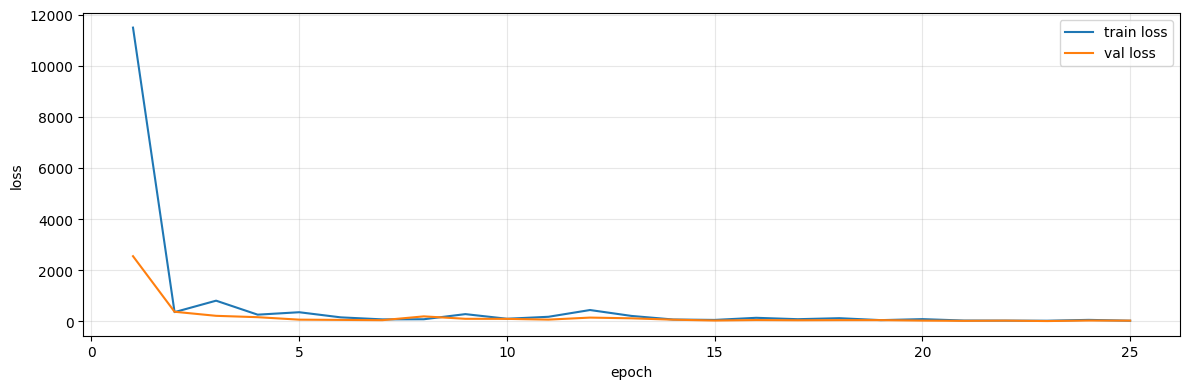

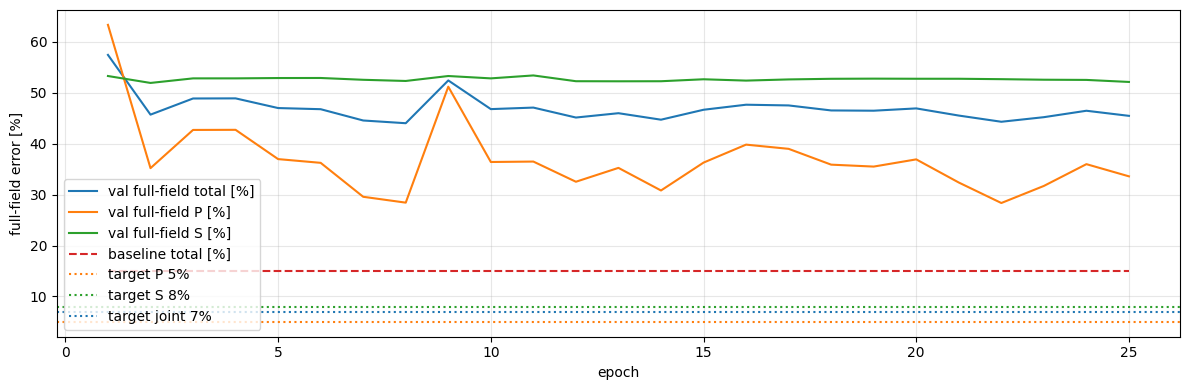

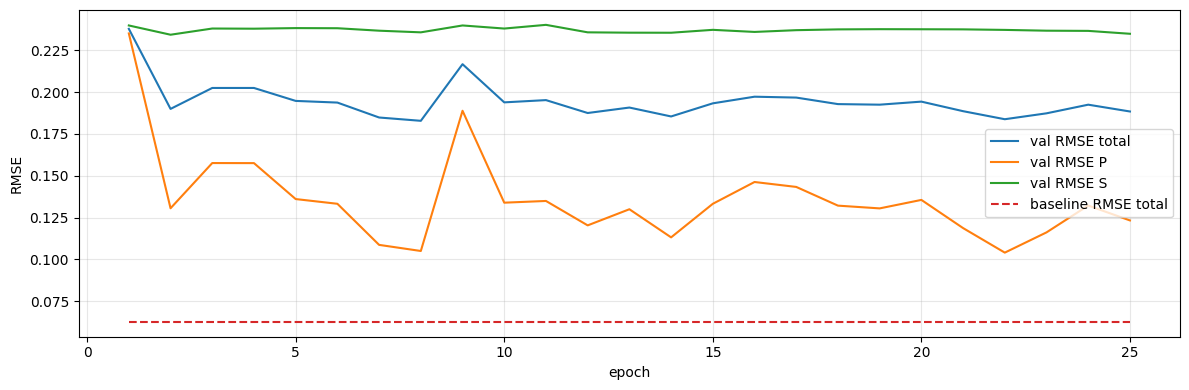

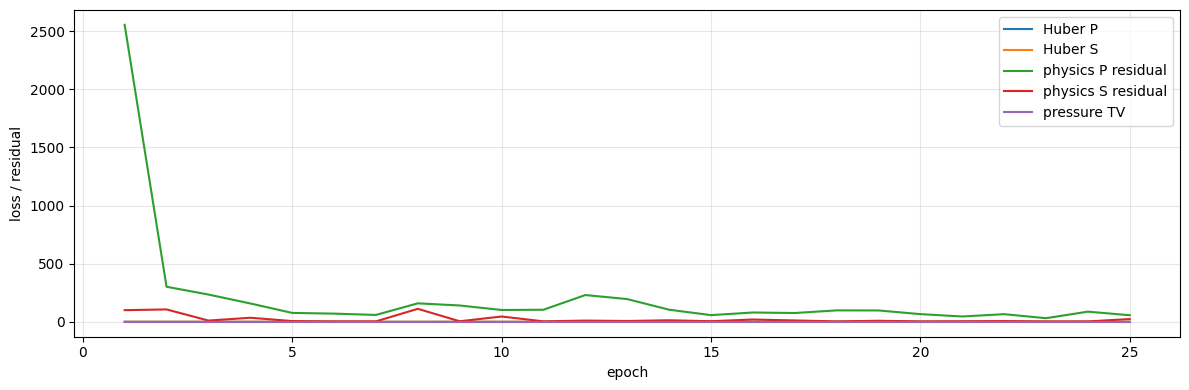

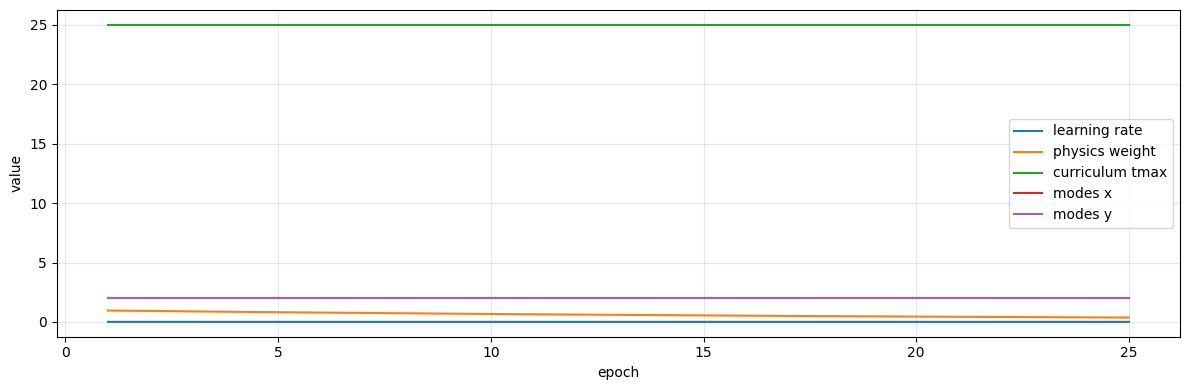

In [13]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["val_ff_total"], label="val full-field total [%]")
plt.plot(epochs, history["val_ff_P"], label="val full-field P [%]")
plt.plot(epochs, history["val_ff_S"], label="val full-field S [%]")
plt.plot(epochs, history["base_ff_total"], "--", label="baseline total [%]")
plt.axhline(cfg.target_ff_P, color="C1", linestyle=":", label="target P 5%")
plt.axhline(cfg.target_ff_S, color="C2", linestyle=":", label="target S 8%")
plt.axhline(cfg.target_ff_joint, color="C0", linestyle=":", label="target joint 7%")
plt.xlabel("epoch"); plt.ylabel("full-field error [%]"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["val_rmse_total"], label="val RMSE total")
plt.plot(epochs, history["val_rmse_P"], label="val RMSE P")
plt.plot(epochs, history["val_rmse_S"], label="val RMSE S")
plt.plot(epochs, history["base_rmse_total"], "--", label="baseline RMSE total")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["data_p"], label="Huber P")
plt.plot(epochs, history["data_s"], label="Huber S")
plt.plot(epochs, history["phys_p"], label="physics P residual")
plt.plot(epochs, history["phys_s"], label="physics S residual")
plt.plot(epochs, history["tv"], label="pressure TV")
plt.xlabel("epoch"); plt.ylabel("loss / residual"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["lr"], label="learning rate")
plt.plot(epochs, history["phys_w"], label="physics weight")
plt.plot(epochs, history["curriculum_tmax"], label="curriculum tmax")
plt.plot(epochs, history["curriculum_modes_x"], label="modes x")
plt.plot(epochs, history["curriculum_modes_y"], label="modes y")
plt.xlabel("epoch"); plt.ylabel("value"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Тест: baseline / SR / HR / error и автоматическая проверка целевых порогов

In [14]:

model.eval()
batch = test_ds[0]
with torch.no_grad():
    lr_test = batch["lr"].unsqueeze(0).to(device)
    hr_test = batch["hr"].unsqueeze(0).to(device)
    K_test = batch["K"].unsqueeze(0).to(device)
    H_test = batch["H"].unsqueeze(0).to(device)
    m_test = batch["m"].unsqueeze(0).to(device)
    inj_test = batch["inj"].unsqueeze(0).to(device)
    prod_test = batch["prod"].unsqueeze(0).to(device)
    sr_raw, base_raw = model(lr_test, K_test, H_test, m_test, inj_test, prod_test)
    tmin = min(sr_raw.shape[1], hr_test.shape[1])
    sr_raw = sr_raw[:, :tmin]
    base_raw = base_raw[:, :tmin]
    hr_test = hr_test[:, :tmin]
    sr_test = enforce_bc_batch(sr_raw, inj_test, prod_test, cfg)
    base_test = enforce_bc_batch(base_raw, inj_test, prod_test, cfg)

hr_np = hr_test[0].cpu().numpy()
sr_np = sr_test[0].cpu().numpy()
base_np = base_test[0].cpu().numpy()

base_metrics = metric_pack(base_test, hr_test)
sr_metrics = metric_pack(sr_test, hr_test)
base_checks = threshold_report(base_metrics, cfg)
sr_checks = threshold_report(sr_metrics, cfg)

print("baseline full-field metrics [%]:", base_metrics)
print("SR full-field metrics [%]:", sr_metrics)
print("SR gain total [% points]:", base_metrics["ff_total"] - sr_metrics["ff_total"])
print("threshold checks (baseline):", base_checks)
print("threshold checks (SR):", sr_checks)


baseline full-field metrics [%]: {'ff_total': 14.859478175640106, 'ff_P': 10.738663375377655, 'ff_S': 16.858379542827606, 'rmse_total': 0.06965145468711853, 'rmse_P': 0.0436156690120697, 'rmse_S': 0.08831945061683655}
SR full-field metrics [%]: {'ff_total': 40.43121337890625, 'ff_P': 24.14710521697998, 'ff_S': 47.610267996788025, 'rmse_total': 0.1895149201154709, 'rmse_P': 0.0980747863650322, 'rmse_S': 0.24942566454410553}
SR gain total [% points]: -25.571735203266144
threshold checks (baseline): {'P<5%': False, 'S<8%': False, 'joint<7%': False}
threshold checks (SR): {'P<5%': False, 'S<8%': False, 'joint<7%': False}


In [15]:

mid_t = cfg.nt_hr - 1
fig, axes = plt.subplots(2, 4, figsize=(15, 7))

# P
titles = ["LR upsampled: P", "PhySR SR: P", "HR truth: P", "|SR-HR|: P"]
panels = [base_np[mid_t, 0], sr_np[mid_t, 0], hr_np[mid_t, 0], np.abs(sr_np[mid_t, 0] - hr_np[mid_t, 0])]
for j in range(4):
    im = axes[0, j].imshow(panels[j])
    axes[0, j].set_title(titles[j]); plt.colorbar(im, ax=axes[0, j], fraction=0.046)

# S
titles = ["LR upsampled: S", "PhySR SR: S", "HR truth: S", "|SR-HR|: S"]
panels = [base_np[mid_t, 1], sr_np[mid_t, 1], hr_np[mid_t, 1], np.abs(sr_np[mid_t, 1] - hr_np[mid_t, 1])]
for j in range(4):
    im = axes[1, j].imshow(panels[j], vmin=cfg.Swc, vmax=cfg.Smax if j < 3 else None)
    axes[1, j].set_title(titles[j]); plt.colorbar(im, ax=axes[1, j], fraction=0.046)

plt.tight_layout()
plt.show()


P full-field [%]     | baseline=10.739 | SR=24.147 | target= 5.00 | pass=False
S full-field [%]     | baseline=16.858 | SR=47.610 | target= 8.00 | pass=False
Joint full-field [%] | baseline=14.859 | SR=40.431 | target= 7.00 | pass=False


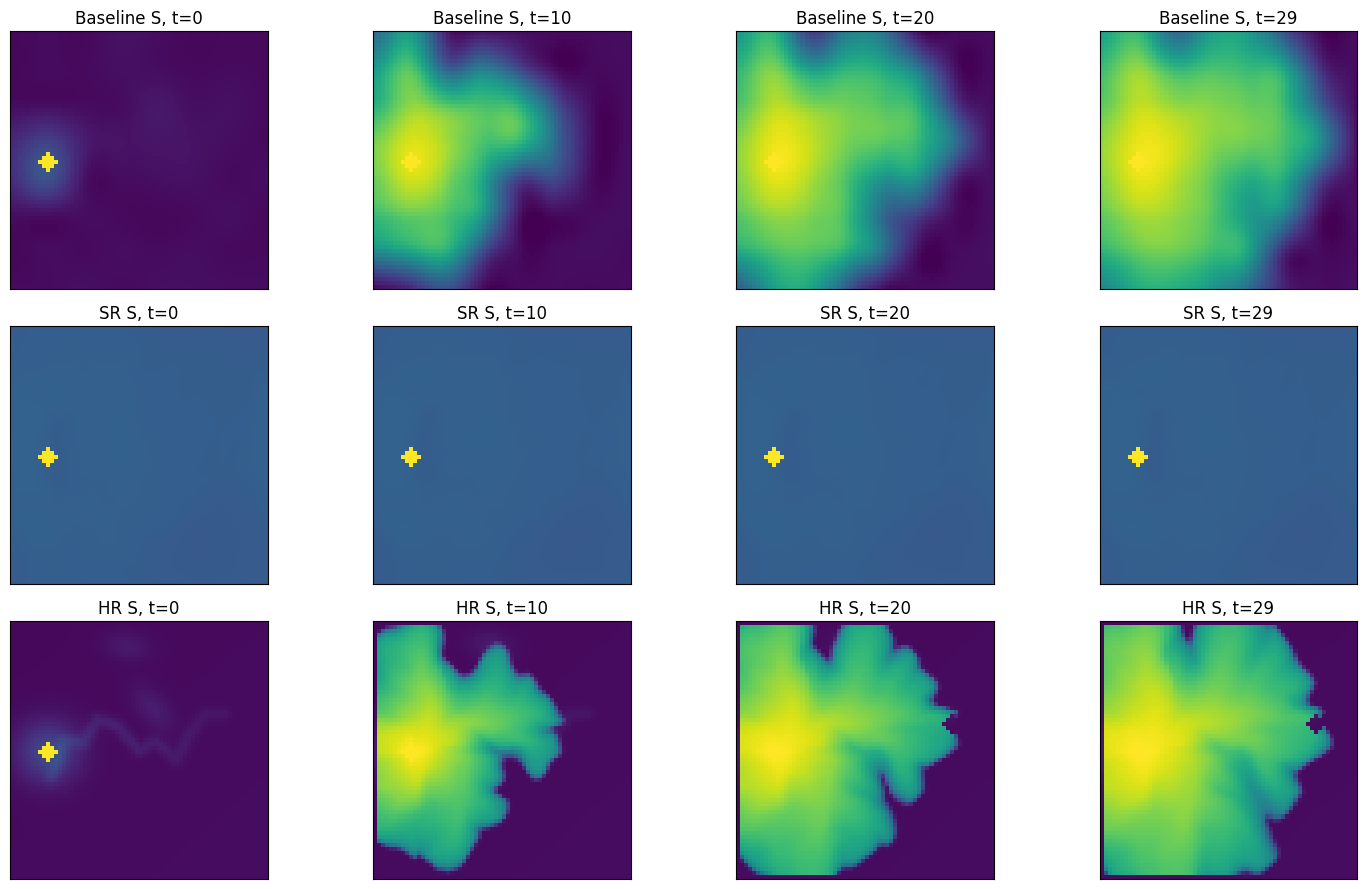

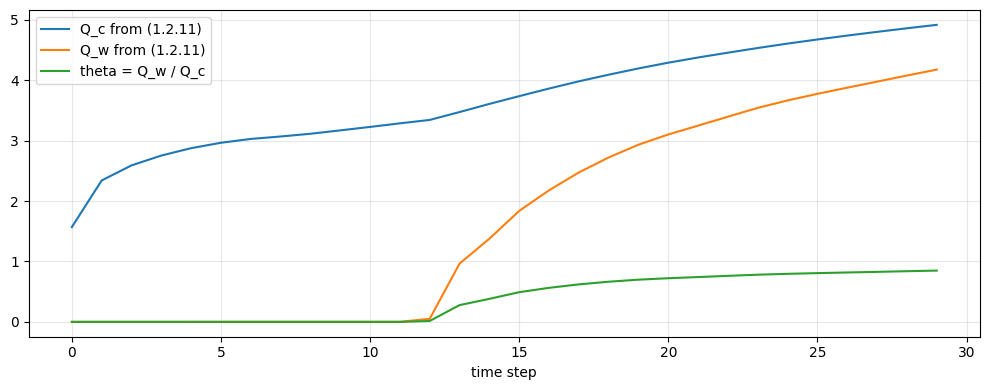

In [16]:
summary_rows = [
    ["P full-field [%]", base_metrics["ff_P"], sr_metrics["ff_P"], cfg.target_ff_P, sr_checks["P<5%"]],
    ["S full-field [%]", base_metrics["ff_S"], sr_metrics["ff_S"], cfg.target_ff_S, sr_checks["S<8%"]],
    ["Joint full-field [%]", base_metrics["ff_total"], sr_metrics["ff_total"], cfg.target_ff_joint, sr_checks["joint<7%"]],
]
for row in summary_rows:
    print(f"{row[0]:20s} | baseline={row[1]:6.3f} | SR={row[2]:6.3f} | target={row[3]:5.2f} | pass={row[4]}")

times = [0, cfg.nt_hr // 3, 2 * cfg.nt_hr // 3, cfg.nt_hr - 1]
fig, axes = plt.subplots(3, len(times), figsize=(3.8 * len(times), 9))
for j, t in enumerate(times):
    im0 = axes[0, j].imshow(base_np[t, 1], vmin=cfg.Swc, vmax=cfg.Smax)
    axes[0, j].set_title(f"Baseline S, t={t}")
    im1 = axes[1, j].imshow(sr_np[t, 1], vmin=cfg.Swc, vmax=cfg.Smax)
    axes[1, j].set_title(f"SR S, t={t}")
    im2 = axes[2, j].imshow(hr_np[t, 1], vmin=cfg.Swc, vmax=cfg.Smax)
    axes[2, j].set_title(f"HR S, t={t}")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
plt.plot(batch["Qc"].numpy(), label="Q_c from (1.2.11)")
plt.plot(batch["Qw"].numpy(), label="Q_w from (1.2.11)")
plt.plot(batch["watercut"].numpy(), label="theta = Q_w / Q_c")
plt.xlabel("time step"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


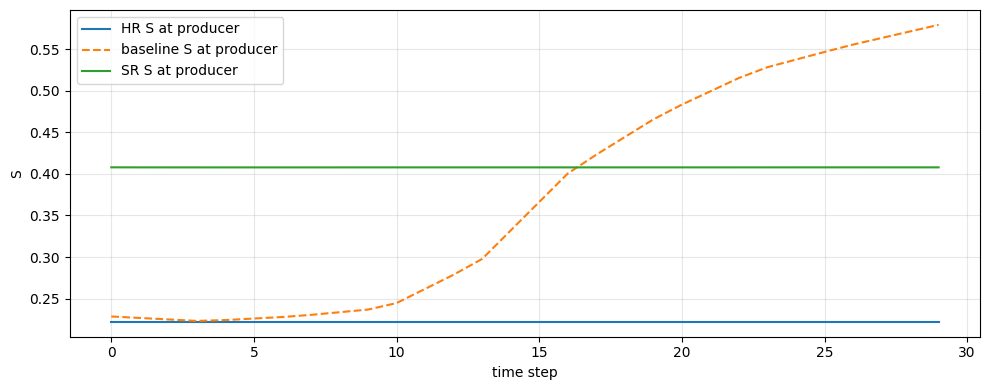

In [17]:
prod_idx = np.argwhere(batch["prod"].cpu().numpy())
py, px = prod_idx.mean(axis=0).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(hr_np[:, 1, py, px], label="HR S at producer")
plt.plot(base_np[:, 1, py, px], "--", label="baseline S at producer")
plt.plot(sr_np[:, 1, py, px], label="SR S at producer")
plt.xlabel("time step"); plt.ylabel("S"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Comprehensive metrics

In [18]:
# ============================================================
# Comprehensive evaluation: accuracy, physics, speed, memory
# Saves results to JSON
# ============================================================
import json
import time
import platform
import tracemalloc
from pathlib import Path
from datetime import datetime

try:
    import psutil
except ImportError:
    psutil = None

METRICS_DIR = Path("metrics")
METRICS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_JSON = METRICS_DIR / f"{NAME}_db_afno_metrics.json"


def _sync_cuda():
    if isinstance(device, torch.device):
        is_cuda = device.type == "cuda"
    else:
        is_cuda = str(device).startswith("cuda")
    if is_cuda and torch.cuda.is_available():
        torch.cuda.synchronize()


def _to_float(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    if isinstance(x, (np.floating, np.integer)):
        return float(x)
    return float(x)


def model_num_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": int(total), "trainable": int(trainable)}


@torch.no_grad()
def rel_l2_percent(pred, target, eps=1e-12):
    return _to_float(
        100.0 * torch.linalg.vector_norm(pred - target) /
        (torch.linalg.vector_norm(target) + eps)
    )


@torch.no_grad()
def rmse_value(pred, target):
    return _to_float(torch.sqrt(torch.mean((pred - target) ** 2)))


@torch.no_grad()
def mae_value(pred, target):
    return _to_float(torch.mean(torch.abs(pred - target)))


@torch.no_grad()
def normalize_field(x, mean, std):
    mean_t = mean.to(x.device).view(1, 1, -1, 1, 1)
    std_t = std.to(x.device).view(1, 1, -1, 1, 1)
    return (x - mean_t) / (std_t + 1e-8)


@torch.no_grad()
def full_field_metrics(pred, target, mean=None, std=None, prefix=""):
    """
    pred, target: [B, T, 2, H, W]
    Channel 0 = P, channel 1 = S.
    """
    pred_p = pred[:, :, 0]
    pred_s = pred[:, :, 1]
    true_p = target[:, :, 0]
    true_s = target[:, :, 1]

    rel_p = rel_l2_percent(pred_p, true_p)
    rel_s = rel_l2_percent(pred_s, true_s)

    out = {
        f"{prefix}rel_l2_P_pct": rel_p,
        f"{prefix}rel_l2_S_pct": rel_s,
        f"{prefix}rmse_P": rmse_value(pred_p, true_p),
        f"{prefix}rmse_S": rmse_value(pred_s, true_s),
        f"{prefix}mae_P": mae_value(pred_p, true_p),
        f"{prefix}mae_S": mae_value(pred_s, true_s),

        # Raw full-field metric over [P, S].
        # This may be dominated by the pressure channel if P and S scales differ.
        f"{prefix}rel_l2_full_raw_pct": rel_l2_percent(pred, target),
        f"{prefix}rmse_full_raw": rmse_value(pred, target),
        f"{prefix}mae_full_raw": mae_value(pred, target),

        # Balanced metric: pressure and saturation contribute equally.
        f"{prefix}rel_l2_full_balanced_pct": 0.5 * (rel_p + rel_s),
    }

    if mean is not None and std is not None:
        pred_n = normalize_field(pred, mean, std)
        target_n = normalize_field(target, mean, std)

        out.update({
            f"{prefix}rel_l2_full_norm_pct": rel_l2_percent(pred_n, target_n),
            f"{prefix}rmse_full_norm": rmse_value(pred_n, target_n),
            f"{prefix}mae_full_norm": mae_value(pred_n, target_n),
        })

    return out


@torch.no_grad()
def saturation_bounds_violation(S, s_min=0.0, s_max=1.0):
    below = torch.clamp(s_min - S, min=0.0)
    above = torch.clamp(S - s_max, min=0.0)
    viol = below + above
    return {
        "mean_violation": _to_float(viol.mean()),
        "max_violation": _to_float(viol.max()),
        "fraction_violated": _to_float((viol > 0).float().mean()),
        "S_min": _to_float(S.min()),
        "S_max": _to_float(S.max()),
    }


@torch.no_grad()
def front_iou(pred_s, target_s, threshold=None):
    if threshold is None:
        threshold = 0.5 * (cfg.Swc + cfg.Smax)
    pred_mask = pred_s >= threshold
    target_mask = target_s >= threshold
    inter = (pred_mask & target_mask).float().sum()
    union = (pred_mask | target_mask).float().sum()
    if union.item() == 0:
        return 1.0
    return _to_float(inter / union)


@torch.no_grad()
def front_centroid_error(pred_s, target_s, threshold=None):
    if threshold is None:
        threshold = 0.5 * (cfg.Swc + cfg.Smax)

    pm = (pred_s >= threshold).float()
    tm = (target_s >= threshold).float()
    B, T, H, W = pred_s.shape

    yy = torch.linspace(0, 1, H, device=pred_s.device).view(1, 1, H, 1)
    xx = torch.linspace(0, 1, W, device=pred_s.device).view(1, 1, 1, W)

    def centroid(mask):
        mass = mask.sum(dim=(-2, -1)).clamp_min(1.0)
        cy = (mask * yy).sum(dim=(-2, -1)) / mass
        cx = (mask * xx).sum(dim=(-2, -1)) / mass
        valid = mask.sum(dim=(-2, -1)) > 0
        return cy, cx, valid

    py, px, pv = centroid(pm)
    ty, tx, tv = centroid(tm)
    valid = pv & tv

    if valid.float().sum().item() == 0:
        return None

    dist = torch.sqrt((py - ty) ** 2 + (px - tx) ** 2) / np.sqrt(2.0)
    return _to_float(dist[valid].mean())


@torch.no_grad()
def complex_zone_mask(hr, K, q_s_grad=0.75, q_k_grad=0.80):
    # hr: [B,T,2,H,W], K: [B,H,W]
    S = hr[:, :, 1]
    front = (S > (cfg.Swc + 0.04)) & (S < (cfg.Smax - 0.04))

    gx = torch.zeros_like(S)
    gy = torch.zeros_like(S)
    gx[..., :, :-1] = S[..., :, 1:] - S[..., :, :-1]
    gy[..., :-1, :] = S[..., 1:, :] - S[..., :-1, :]
    gmag = torch.sqrt(gx ** 2 + gy ** 2 + 1e-12)

    B, T, H, W = gmag.shape
    gthr = torch.quantile(gmag.reshape(B, T, -1), q_s_grad, dim=-1).view(B, T, 1, 1)
    s_grad_zone = gmag >= gthr

    logK = torch.log(K.clamp_min(1e-8))
    kgx = torch.zeros_like(logK)
    kgy = torch.zeros_like(logK)
    kgx[..., :, :-1] = logK[..., :, 1:] - logK[..., :, :-1]
    kgy[..., :-1, :] = logK[..., 1:, :] - logK[..., :-1, :]
    kgmag = torch.sqrt(kgx ** 2 + kgy ** 2 + 1e-12)

    kthr = torch.quantile(kgmag.reshape(B, -1), q_k_grad, dim=-1).view(B, 1, 1)
    k_zone = (kgmag >= kthr).unsqueeze(1).expand(-1, T, -1, -1)

    return (front | s_grad_zone | k_zone).float()


@torch.no_grad()
def masked_rel_l2_percent(pred, target, mask, eps=1e-12):
    if mask.ndim == pred.ndim - 1:
        mask = mask.unsqueeze(2)
    mask = mask.expand_as(pred).float()

    num = torch.sqrt(((pred - target) ** 2 * mask).sum())
    den = torch.sqrt((target ** 2 * mask).sum()) + eps

    return _to_float(100.0 * num / den)


@torch.no_grad()
def masked_rmse(pred, target, mask):
    if mask.ndim == pred.ndim - 1:
        mask = mask.unsqueeze(2)
    mask = mask.expand_as(pred).float()

    return _to_float(
        torch.sqrt(((pred - target) ** 2 * mask).sum() / mask.sum().clamp_min(1.0))
    )


@torch.no_grad()
def global_mass_balance_proxy(S, inj, prod, Qc=None, Qw=None, dt_frame=None):
    # Proxy: exact control-volume fluxes are not stored in HDF5.
    B, T, H, W = S.shape

    accumulation = S[:, -1].mean(dim=(-2, -1)) - S[:, 0].mean(dim=(-2, -1))
    out = {
        "mean_saturation_accumulation": _to_float(accumulation.mean()),
        "mean_saturation_accumulation_abs": _to_float(accumulation.abs().mean()),
    }

    if Qw is not None and dt_frame is not None and dt_frame.numel() > 0:
        q_mid = 0.5 * (Qw[:, 1:] + Qw[:, :-1])
        produced_water = (q_mid * dt_frame).sum(dim=1)

        out["cumulative_produced_water_mean"] = _to_float(produced_water.mean())
        out["cumulative_produced_water_abs_mean"] = _to_float(produced_water.abs().mean())
        out["accumulation_minus_produced_water_mean"] = _to_float(
            (accumulation - produced_water).mean()
        )
        out["accumulation_minus_produced_water_abs_mean"] = _to_float(
            (accumulation - produced_water).abs().mean()
        )

    return out


@torch.no_grad()
def breakthrough_time_from_watercut(watercut, dt_frame, threshold=0.01):
    wc = watercut.detach().cpu().float().numpy()
    if dt_frame is not None and len(dt_frame):
        dt = dt_frame.detach().cpu().float().numpy()
    else:
        dt = np.ones(max(0, len(wc) - 1), dtype=np.float32)

    t = np.concatenate([[0.0], np.cumsum(dt)])
    above = np.where(wc >= threshold)[0]

    if len(above) == 0:
        return {
            "reached": False,
            "frame": None,
            "time": None,
            "max_watercut": float(np.max(wc)),
        }

    i = int(above[0])

    if i == 0:
        t_bt = float(t[0])
    else:
        w0, w1 = wc[i - 1], wc[i]
        alpha = 0.0 if abs(w1 - w0) < 1e-12 else float((threshold - w0) / (w1 - w0))
        alpha = max(0.0, min(1.0, alpha))
        t_bt = float(t[i - 1] + alpha * (t[i] - t[i - 1]))

    return {
        "reached": True,
        "frame": i,
        "time": t_bt,
        "max_watercut": float(np.max(wc)),
    }


@torch.no_grad()
def predicted_watercut_proxy(S, prod, cfg):
    prod_f = prod.float()
    denom = prod_f.sum(dim=(-2, -1)).clamp_min(1.0)
    return (S * prod_f[:, None]).sum(dim=(-2, -1)) / denom[:, None]


@torch.no_grad()
def forward_model_for_metrics(model, batch):
    lr = batch["lr"].to(device)
    K = batch["K"].to(device)
    H = batch["H"].to(device)
    m = batch["m"].to(device)
    inj = batch["inj"].to(device)
    prod = batch["prod"].to(device)

    out = model(lr, K, H, m, inj, prod)

    if isinstance(out, tuple):
        pred_raw, base_raw = out[:2]
    else:
        pred_raw = out
        base_raw = spatial_interp(
            temporal_interp(lr, cfg.nt_hr),
            (cfg.ny_hr, cfg.nx_hr)
        )

    pred = enforce_bc_batch(pred_raw, inj, prod, cfg)
    base = enforce_bc_batch(base_raw, inj, prod, cfg)

    return pred, base


@torch.no_grad()
def forward_base_for_metrics(batch):
    lr = batch["lr"].to(device)
    inj = batch["inj"].to(device)
    prod = batch["prod"].to(device)

    base_raw = spatial_interp(
        temporal_interp(lr, cfg.nt_hr),
        (cfg.ny_hr, cfg.nx_hr)
    )
    return enforce_bc_batch(base_raw, inj, prod, cfg)


@torch.no_grad()
def evaluate_full_metrics(model, loader, cfg, max_batches=None, wc_threshold=0.01):
    model.eval()

    sample_rows = []
    mean_eval = mean.to(device) if "mean" in globals() and isinstance(mean, torch.Tensor) else None
    std_eval = std.to(device) if "std" in globals() and isinstance(std, torch.Tensor) else None

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        hr = batch["hr"].to(device)
        K = batch["K"].to(device)

        pred, base = forward_model_for_metrics(model, batch)
        tmin = min(pred.shape[1], hr.shape[1])
        pred = pred[:, :tmin]
        base = base[:, :tmin]
        hr = hr[:, :tmin]

        pred_s = pred[:, :, 1]
        hr_s = hr[:, :, 1]
        base_s = base[:, :, 1]

        cz = complex_zone_mask(hr, K)

        row = {}

        # Full-field metrics: P, S, raw full, balanced full, normalized full.
        row.update(full_field_metrics(pred, hr, mean_eval, std_eval, prefix=""))
        row.update(full_field_metrics(base, hr, mean_eval, std_eval, prefix="base_"))

        # Backward-compatible names.
        row["rel_l2_total_pct"] = row["rel_l2_full_raw_pct"]
        row["rmse_total"] = row["rmse_full_raw"]
        row["base_rel_l2_total_pct"] = row["base_rel_l2_full_raw_pct"]

        # Front metrics.
        row.update({
            "front_iou": front_iou(pred_s, hr_s),
            "base_front_iou": front_iou(base_s, hr_s),
            "front_centroid_error_norm": front_centroid_error(pred_s, hr_s),
            "base_front_centroid_error_norm": front_centroid_error(base_s, hr_s),
        })

        # Complex-zone metrics.
        row.update({
            "complex_rel_l2_full_raw_pct": masked_rel_l2_percent(pred, hr, cz),
            "complex_rel_l2_total_pct": masked_rel_l2_percent(pred, hr, cz),
            "complex_rel_l2_P_pct": masked_rel_l2_percent(pred[:, :, 0], hr[:, :, 0], cz),
            "complex_rel_l2_S_pct": masked_rel_l2_percent(pred_s, hr_s, cz),
            "complex_rmse_S": masked_rmse(pred_s, hr_s, cz),

            "base_complex_rel_l2_full_raw_pct": masked_rel_l2_percent(base, hr, cz),
            "base_complex_rel_l2_total_pct": masked_rel_l2_percent(base, hr, cz),
            "base_complex_rel_l2_P_pct": masked_rel_l2_percent(base[:, :, 0], hr[:, :, 0], cz),
            "base_complex_rel_l2_S_pct": masked_rel_l2_percent(base_s, hr_s, cz),
            "base_complex_rmse_S": masked_rmse(base_s, hr_s, cz),
        })

        # Gains over interpolation/base. Positive = improvement.
        for metric in [
            "rel_l2_S_pct",
            "rel_l2_P_pct",
            "rel_l2_full_raw_pct",
            "rel_l2_full_balanced_pct",
            "rmse_S",
            "rmse_P",
            "rmse_full_raw",
        ]:
            base_key = f"base_{metric}"
            if metric in row and base_key in row:
                row[f"gain_{metric.replace('_pct', '')}"] = (
                    row[base_key] - row[metric]
                ) / max(row[base_key], 1e-12)

        if "rel_l2_full_norm_pct" in row and "base_rel_l2_full_norm_pct" in row:
            row["gain_rel_l2_full_norm"] = (
                row["base_rel_l2_full_norm_pct"] - row["rel_l2_full_norm_pct"]
            ) / max(row["base_rel_l2_full_norm_pct"], 1e-12)

        row["gain_front_iou"] = row["front_iou"] - row["base_front_iou"]

        # Saturation physical bounds.
        row.update({
            f"S_bounds_{k}": v
            for k, v in saturation_bounds_violation(pred_s, 0.0, 1.0).items()
        })
        row.update({
            f"base_S_bounds_{k}": v
            for k, v in saturation_bounds_violation(base_s, 0.0, 1.0).items()
        })

        # Proxy mass-balance diagnostics.
        if "Qw" in batch and "dt_frame" in batch:
            mb_ref = global_mass_balance_proxy(
                hr_s,
                batch["inj"].to(device),
                batch["prod"].to(device),
                Qw=batch["Qw"].to(device),
                dt_frame=batch["dt_frame"].to(device),
            )
            row.update({f"mass_proxy_ref_{k}": v for k, v in mb_ref.items()})

            # Prediction-only accumulation proxy.
            mb_pred = global_mass_balance_proxy(
                pred_s,
                batch["inj"].to(device),
                batch["prod"].to(device),
                Qw=None,
                dt_frame=None,
            )
            row.update({f"mass_proxy_pred_{k}": v for k, v in mb_pred.items()})

            row["mass_proxy_accumulation_abs_error"] = abs(
                row["mass_proxy_pred_mean_saturation_accumulation"] -
                row["mass_proxy_ref_mean_saturation_accumulation"]
            )

        # Breakthrough diagnostics, if stored watercut exists.
        if "watercut" in batch:
            bt_ref = []
            for b in range(batch["watercut"].shape[0]):
                dt_b = batch["dt_frame"][b] if "dt_frame" in batch else torch.ones_like(batch["watercut"][b, :-1])
                bt_ref.append(
                    breakthrough_time_from_watercut(
                        batch["watercut"][b],
                        dt_b,
                        wc_threshold
                    )
                )

            row["reference_breakthrough_fraction"] = float(np.mean([x["reached"] for x in bt_ref]))

            reached_times = [x["time"] for x in bt_ref if x["reached"]]
            row["reference_breakthrough_time_mean"] = float(np.mean(reached_times)) if reached_times else None
            row["reference_max_watercut_mean"] = float(np.mean([x["max_watercut"] for x in bt_ref]))

            pred_wc_proxy = predicted_watercut_proxy(pred_s, batch["prod"].to(device), cfg).detach().cpu()
            base_wc_proxy = predicted_watercut_proxy(base_s, batch["prod"].to(device), cfg).detach().cpu()
            ref_wc_proxy = predicted_watercut_proxy(hr_s, batch["prod"].to(device), cfg).detach().cpu()

            row["producer_saturation_proxy_mae_pred"] = float(torch.mean(torch.abs(pred_wc_proxy - ref_wc_proxy)))
            row["producer_saturation_proxy_mae_base"] = float(torch.mean(torch.abs(base_wc_proxy - ref_wc_proxy)))
            row["producer_saturation_proxy_rmse_pred"] = float(torch.sqrt(torch.mean((pred_wc_proxy - ref_wc_proxy) ** 2)))
            row["producer_saturation_proxy_rmse_base"] = float(torch.sqrt(torch.mean((base_wc_proxy - ref_wc_proxy) ** 2)))

        sample_rows.append({
            k: (None if v is None else float(v))
            for k, v in row.items()
        })

    summary = {}
    keys = sorted(set().union(*[r.keys() for r in sample_rows])) if sample_rows else []

    for k in keys:
        vals = [
            r[k] for r in sample_rows
            if k in r and r[k] is not None and np.isfinite(r[k])
        ]
        if vals:
            summary[k] = {
                "mean": float(np.mean(vals)),
                "std": float(np.std(vals)),
                "min": float(np.min(vals)),
                "max": float(np.max(vals)),
            }

    return summary, sample_rows


def measure_inference_performance(model, loader, cfg, n_warmup=3, n_runs=20):
    model.eval()

    model_times = []
    base_times = []

    if torch.cuda.is_available() and str(device).startswith("cuda"):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    process = psutil.Process() if psutil is not None else None
    rss_before = process.memory_info().rss if process is not None else None

    tracemalloc.start()

    with torch.no_grad():
        it = iter(loader)

        for _ in range(n_warmup):
            try:
                batch = next(it)
            except StopIteration:
                it = iter(loader)
                batch = next(it)

            _ = forward_model_for_metrics(model, batch)
            _ = forward_base_for_metrics(batch)

        _sync_cuda()

        it = iter(loader)

        for _ in range(n_runs):
            try:
                batch = next(it)
            except StopIteration:
                it = iter(loader)
                batch = next(it)

            _sync_cuda()
            t0 = time.perf_counter()
            _ = forward_model_for_metrics(model, batch)
            _sync_cuda()
            model_times.append(time.perf_counter() - t0)

            _sync_cuda()
            t0 = time.perf_counter()
            _ = forward_base_for_metrics(batch)
            _sync_cuda()
            base_times.append(time.perf_counter() - t0)

    current, peak_py = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    rss_after = process.memory_info().rss if process is not None else None

    gpu = {}
    if torch.cuda.is_available() and str(device).startswith("cuda"):
        gpu = {
            "peak_allocated_mb": float(torch.cuda.max_memory_allocated() / 1024**2),
            "peak_reserved_mb": float(torch.cuda.max_memory_reserved() / 1024**2),
        }

    batch_size = int(getattr(batch, "shape", [1])[0]) if False else int(batch["hr"].shape[0])
    model_mean = float(np.mean(model_times))
    base_mean = float(np.mean(base_times))

    perf = {
        "batch_size": batch_size,

        "inference_time_sec_per_batch_mean": model_mean,
        "inference_time_sec_per_batch_std": float(np.std(model_times)),
        "inference_time_sec_per_batch_p50": float(np.percentile(model_times, 50)),
        "inference_time_sec_per_batch_p95": float(np.percentile(model_times, 95)),
        "inference_time_sec_per_sample_mean": model_mean / max(1, batch_size),
        "throughput_samples_per_sec": float(max(1, batch_size) / model_mean),

        "base_interpolation_time_sec_per_batch_mean": base_mean,
        "base_interpolation_time_sec_per_batch_std": float(np.std(base_times)),
        "base_interpolation_time_sec_per_sample_mean": base_mean / max(1, batch_size),
        "base_interpolation_speedup_vs_model": float(model_mean / max(base_mean, 1e-12)),

        "python_peak_tracemalloc_mb": float(peak_py / 1024**2),
        "cpu_rss_delta_mb": None if rss_before is None else float((rss_after - rss_before) / 1024**2),
        "gpu": gpu,
    }

    return perf


def measure_solver_generation_time_if_available(cfg, n_cases=3):
    if globals().get("USING_H5_DATASET", False):
        return None
    if "simulate_case" not in globals():
        return None

    times = []

    for i in range(n_cases):
        t0 = time.perf_counter()
        _ = simulate_case(10_000 + i, cfg)
        times.append(time.perf_counter() - t0)

    return {
        "n_cases": int(n_cases),
        "time_sec_per_case_mean": float(np.mean(times)),
        "time_sec_per_case_std": float(np.std(times)),
    }


# Run and save metrics.
if "best" in globals() and isinstance(best, dict) and best.get("state") is not None:
    model.load_state_dict(best["state"])

accuracy_summary, accuracy_rows = evaluate_full_metrics(
    model,
    test_loader,
    cfg,
    wc_threshold=0.01
)

performance_summary = measure_inference_performance(
    model,
    test_loader,
    cfg,
    n_warmup=3,
    n_runs=min(20, len(test_loader))
)

solver_timing = measure_solver_generation_time_if_available(cfg, n_cases=1)

if solver_timing is not None:
    model_t = performance_summary["inference_time_sec_per_sample_mean"]
    solver_t = solver_timing["time_sec_per_case_mean"]
    performance_summary["speedup_vs_python_solver"] = float(solver_t / max(model_t, 1e-12))
else:
    performance_summary["speedup_vs_python_solver"] = None

training_summary = {
    "training_time_total_sec": (
        float(globals().get("training_time_total_sec", np.nan))
        if "training_time_total_sec" in globals()
        else None
    ),
    "training_time_per_epoch_sec": (
        float(globals().get("training_time_per_epoch_sec", np.nan))
        if "training_time_per_epoch_sec" in globals()
        else None
    ),
    "epochs_completed": int(
        globals().get(
            "training_epochs_completed",
            len(history.get("train_loss", [])) if "history" in globals() else 0
        )
    ),
    "best_epoch": int(best.get("epoch", 0)) if "best" in globals() and isinstance(best, dict) else None,
    "best_score": float(best.get("score", np.nan)) if "best" in globals() and isinstance(best, dict) else None,
    "history": history if "history" in globals() else None,
}

cfg_dict = dict(getattr(cfg, "__dict__", {}))

for k, v in list(cfg_dict.items()):
    if isinstance(v, (np.integer, np.floating)):
        cfg_dict[k] = float(v)
    elif isinstance(v, torch.device):
        cfg_dict[k] = str(v)
    elif isinstance(v, Path):
        cfg_dict[k] = str(v)

results = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "dataset": {
        "name": NAME,
        "data_dir": str(DATA_DIR),
        "train_h5": str(TRAIN_H5),
        "val_h5": str(VAL_H5),
        "test_h5": str(TEST_H5),
        "train_size": len(train_ds) if "train_ds" in globals() else None,
        "val_size": len(val_ds) if "val_ds" in globals() else None,
        "test_size": len(test_ds) if "test_ds" in globals() else None,
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda_available": bool(torch.cuda.is_available()),
        "cuda_device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "device": str(device),
    },
    "config": cfg_dict,
    "model": model_num_parameters(model),
    "training": training_summary,
    "performance": performance_summary,
    "solver_timing": solver_timing,
    "accuracy_summary": accuracy_summary,
    "accuracy_per_batch": accuracy_rows,
}

with open(METRICS_JSON, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Saved metrics to: {METRICS_JSON}")
print("\n=== Key metrics ===")
print("Params:", results["model"])
print("Inference sec/sample:", performance_summary["inference_time_sec_per_sample_mean"])
print("Base interpolation sec/sample:", performance_summary["base_interpolation_time_sec_per_sample_mean"])
print("Peak GPU allocated MB:", performance_summary["gpu"].get("peak_allocated_mb") if performance_summary["gpu"] else None)
print("Training total sec:", training_summary["training_time_total_sec"])
print("Speedup vs solver:", performance_summary.get("speedup_vs_python_solver"))

keys_to_print = [
    "rel_l2_full_raw_pct",
    "rel_l2_full_balanced_pct",
    "rel_l2_full_norm_pct",
    "rel_l2_P_pct",
    "rel_l2_S_pct",
    "rmse_full_raw",
    "rmse_full_norm",
    "rmse_P",
    "rmse_S",
    "mae_P",
    "mae_S",
    "front_iou",
    "gain_rel_l2_full_raw",
    "gain_rel_l2_full_norm",
    "gain_rel_l2_S",
    "complex_rel_l2_full_raw_pct",
    "complex_rel_l2_P_pct",
    "complex_rel_l2_S_pct",
    "S_bounds_mean_violation",
    "S_bounds_fraction_violated",
    "mass_proxy_accumulation_abs_error",
]

for key in keys_to_print:
    if key in accuracy_summary:
        print(f"{key}: {accuracy_summary[key]['mean']:.6g} ± {accuracy_summary[key]['std']:.6g}")

Saved metrics to: metrics/synth128_x8_t3_db_afno_metrics.json

=== Key metrics ===
Params: {'total': 24336951, 'trainable': 24336951}
Inference sec/sample: 0.008396205999993356
Base interpolation sec/sample: 0.00023224843749858337
Peak GPU allocated MB: 1187.86083984375
Training total sec: None
Speedup vs solver: None
rel_l2_full_raw_pct: 42.9921 ± 1.99988
rel_l2_full_balanced_pct: 38.8718 ± 2.75195
rel_l2_full_norm_pct: 84.0897 ± 6.58373
rel_l2_P_pct: 26.0193 ± 4.45659
rel_l2_S_pct: 51.7244 ± 3.01618
rmse_full_raw: 0.183061 ± 0.0097855
rmse_full_norm: 0.819753 ± 0.0439313
rmse_P: 0.0992571 ± 0.0116371
rmse_S: 0.238781 ± 0.0145212
mae_P: 0.0726934 ± 0.00703777
mae_S: 0.224155 ± 0.0128577
front_iou: 0.0102737 ± 0.00320956
gain_rel_l2_full_raw: -1.83253 ± 0.135746
gain_rel_l2_full_norm: -1.7467 ± 0.187577
gain_rel_l2_S: -1.92878 ± 0.132729
complex_rel_l2_full_raw_pct: 39.4162 ± 2.04081
complex_rel_l2_P_pct: 27.5348 ± 5.78377
complex_rel_l2_S_pct: 45.0124 ± 1.17961
S_bounds_mean_violation

## 10. Что изменено в этой версии

- Численный генератор оставлен в ноутбуке как reference/backup, но основной pipeline теперь читает данные из HDF5-датасета `*_train.h5`, `*_val.h5`, `*_test.h5` и `config.json`.
- DB-AFNO сохранён: общий Fourier trunk, Time2Vec, causal Transformer, две ветви декодирования для `P` и `S`.
- Для HDF5-данных добавлены `H5FiltrationDataset`, `train_loader`, `val_loader`, `test_loader`.
- Нормировки `state_mean/state_std`, `target_mean/target_std` и `static_mean/static_std` считаются по train split.
- Loss остаётся dual-output physics-informed: Huber по `P,S` + residual для уравнения давления и сохранения массы.
- Добавлен comprehensive metrics block: full-field метрики, RMSE/MAE, complex-zone, front IoU, saturation bounds, speed/memory и экспорт JSON в `metrics/{NAME}_db_afno_metrics.json`.